# Beer Recommender — Hybrid Pipeline: MF → HybridNeuMF → MetadataSASRec
### With Cold-Start Handling, Advanced Feature Engineering & Strict Evaluation

**Methods:**
- He et al., *Neural Collaborative Filtering*, WWW 2017
- Kang & McAuley, *Self-Attentive Sequential Recommendation*, ICDM 2018

**Dataset:** BeerAdvocate + RateBeer (Stanford SNAP)

**Key contributions over baseline NeuMF:**
1. **Feature Engineering** — style embeddings, normalised ABV, 4-dim aspect ratings, style-group popularity, ABV-tier buckets, and review-count popularity signals
2. **Cold-Start Handling** — content-based fallback for new users/items using style-group priors; cold users scored by beer-metadata similarity; cold items scored by style/ABV affinity
3. **MetadataSASRec** — per-position metadata injection (style + ABV + aspect vector) into the transformer encoder, making sequences content-aware

## Table of Contents
1. [Imports & Device](#1)
2. [Data Loading](#2)
3. [Preprocessing, K-Core & Feature Engineering](#3)
4. [Cold-Start Infrastructure](#4)
5. [Chronological Split & ID Mappings](#5)
6. [Shared Evaluation Utilities](#6)
7. [MF Baseline (ID-only)](#7)
8. [HybridNeuMF — GMF Pre-train](#8)
9. [HybridNeuMF — MLP Pre-train](#9)
10. [HybridNeuMF — Fusion & Fine-tune](#10)
11. [Sequential Data Construction](#11)
12. [MetadataSASRec Model](#12)
13. [MetadataSASRec Training](#13)
14. [Rating-Prediction Results](#14)
15. [Ranking Results — All Models](#15)
16. [Cold-Start Evaluation](#16)
17. [Beer Recommendations](#17)


## 1. Imports & Device <a name='1'></a>

In [1]:
import os, ast, copy, math, time
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', 30)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    torch.cuda.empty_cache()
    torch.cuda.manual_seed_all(SEED)
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: Apple MPS')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU')
print('Active device:', DEVICE)


GPU: NVIDIA A100-SXM4-80GB
Active device: cuda


## 2. Data Loading <a name='2'></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE_PATH    = Path('/content/drive/MyDrive/RCCSYS')
SOURCE_FILES = {
    'beeradvocate': BASE_PATH / 'beeradvocate.json',
    'ratebeer':     BASE_PATH / 'ratebeer.json',
}
for name, path in SOURCE_FILES.items():
    status = f'{path.stat().st_size/1e6:.0f} MB' if path.exists() else 'NOT FOUND'
    print(f'  {name:14s} -> {status}')


Mounted at /content/drive
  beeradvocate   -> 1655 MB
  ratebeer       -> 1930 MB


In [3]:
def load_dict_per_line(filepath):
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(ast.literal_eval(line))
    return pd.DataFrame(records)

t0 = time.time()
beer_advocate = load_dict_per_line(SOURCE_FILES['beeradvocate'])
rate_beer     = load_dict_per_line(SOURCE_FILES['ratebeer'])
print(f'Loaded in {time.time()-t0:.1f}s  |  BA: {beer_advocate.shape}  |  RB: {rate_beer.shape}')


Loaded in 279.6s  |  BA: (1586615, 13)  |  RB: (2924164, 13)


## 3. Preprocessing, K-Core & Feature Engineering <a name='3'></a>

### Feature engineering rationale

| Feature | Engineering | Justification |
|---------|-------------|---------------|
| `beer/style` | LabelEncoder → learned embedding (dim 16) | 179 unique style categories; embedding lets the model learn style similarity |
| `beer/ABV` | Divide by 15, clip [0,1] → scalar + 4-bucket one-hot | Continuous signal + coarse bucket for non-linear effects (session/pairing choice) |
| `avg_aspect` | Mean of aroma/appearance/palate/taste (all [0,1]) | Aggregates multi-faceted quality; single scalar reduces noise vs raw 4-dim in MLP |
| `aspect_vec` | Raw [aroma, appearance, palate, taste] (4-dim) | Used in SASRec where per-position richness matters more than compactness |
| `style_pop_prior` | Bayesian mean rating per style group | Cold-start prior — new items in a known style get the style group's mean |
| `log_review_count` | log1p of item review count | Popularity signal; helps model distinguish established beers from long-tail |
| `abv_tier` | Bucketed ABV: session(<4.5), standard(4.5-7), strong(7-10), extreme(>10) | Non-linear categorical encoding of strength — important for preference matching |


In [4]:
RATING_COLS = ['review/appearance', 'review/aroma', 'review/palate',
               'review/taste', 'review/overall']

def parse_rating(val):
    try:
        s = str(val)
        # If it's a fraction like '13/20' or '4/5', calculate it. Result is [0, 1]
        if '/' in s:
            num, denom = s.split('/')
            return float(num) / float(denom)
        # If it's a scalar like '3.5' or '4', assume it's out of 5. Convert to [0, 1]
        return float(s) / 5.0
    except (ValueError, TypeError):
        return np.nan

for col in RATING_COLS:
    beer_advocate[col] = beer_advocate[col].apply(parse_rating)
    rate_beer[col]     = rate_beer[col].apply(parse_rating)

# Ratings are now perfectly normalized to [0, 1]. No need for secondary division.

for df_ in (beer_advocate, rate_beer):
    df_['beer/ABV']    = pd.to_numeric(df_['beer/ABV'],    errors='coerce')
    df_['review/time'] = pd.to_numeric(df_['review/time'], errors='coerce')

beer_advocate['source'] = 'beeradvocate'
rate_beer['source']     = 'ratebeer'
df = pd.concat([beer_advocate, rate_beer], ignore_index=True)
df['item_id'] = df['source'] + '_' + df['beer/beerId'].astype(str)

# Name lookup for recommendations (full dataset, before filtering)
item_name_lookup = (
    df.dropna(subset=['item_id', 'beer/name'])
    .drop_duplicates('item_id')[['item_id','beer/name','beer/style','beer/ABV','source']]
    .set_index('item_id')
)

before = len(df)
df = df.dropna(subset=['review/profileName', 'item_id', 'review/overall']).copy()
df = df.drop_duplicates(subset=['review/profileName', 'item_id'], keep='first').copy()
print(f'After null/dedup: {before:,} → {len(df):,}')

# K-core: min 10 reviews each side, up to 5 iterations
MIN_REVIEWS = 10
for iteration in range(5):
    prev = len(df)
    uc = df['review/profileName'].value_counts()
    ic = df['item_id'].value_counts()
    df = df[df['review/profileName'].isin(uc[uc >= MIN_REVIEWS].index)]
    df = df[df['item_id'].isin(ic[ic >= MIN_REVIEWS].index)]
    df = df.reset_index(drop=True)
    print(f'K-core iter {iteration+1}: {prev:,} → {len(df):,}')
    if len(df) == prev:
        break

print(f'\nFinal: {len(df):,} rows | {df["review/profileName"].nunique():,} users | {df["item_id"].nunique():,} items')

After null/dedup: 4,510,779 → 4,427,040
K-core iter 1: 4,427,040 → 3,955,615
K-core iter 2: 3,955,615 → 3,948,441
K-core iter 3: 3,948,441 → 3,947,948
K-core iter 4: 3,947,948 → 3,947,930
K-core iter 5: 3,947,930 → 3,947,930

Final: 3,947,930 rows | 19,144 users | 48,104 items


In [5]:
# ── Rich feature extraction ────────────────────────────────────────────────────
ASPECT_COLS = ['review/aroma', 'review/appearance', 'review/palate', 'review/taste']

beer_meta = df.groupby('item_id').agg(
    style      = ('beer/style',       'first'),
    abv        = ('beer/ABV',         'first'),
    aroma      = ('review/aroma',     'mean'),
    appearance = ('review/appearance','mean'),
    palate     = ('review/palate',    'mean'),
    taste      = ('review/taste',     'mean'),
    n_reviews  = ('review/overall',   'count'),
    mean_rating= ('review/overall',   'mean'),
).reset_index()

# ── avg_aspect & aspect variance: structural quality signals ───────────────────
beer_meta['avg_aspect'] = beer_meta[['aroma','appearance','palate','taste']].mean(axis=1)
# NEW: Aspect Variance (low = well-rounded, high = polarizing/imbalanced profile)
beer_meta['aspect_var'] = beer_meta[['aroma','appearance','palate','taste']].var(axis=1).fillna(0.0)

# ── Style encoding ────────────────────────────────────────────────────────────
le_style = LabelEncoder()
beer_meta['style_idx'] = le_style.fit_transform(beer_meta['style'].fillna('Unknown'))
n_styles = int(beer_meta['style_idx'].max()) + 1

# ── ABV normalisation + tier buckets ─────────────────────────────────────────
abv_mean = beer_meta['abv'].mean(skipna=True)
beer_meta['abv_norm'] = (beer_meta['abv'].fillna(abv_mean) / 15.0).clip(0.0, 1.0)

def abv_to_tier(abv):
    if pd.isna(abv): return 1          # default: standard
    if abv < 4.5:    return 0          # session
    elif abv < 7.0:  return 1          # standard
    elif abv < 10.0: return 2          # strong
    else:            return 3          # extreme
N_ABV_TIERS = 4
beer_meta['abv_tier'] = beer_meta['abv'].apply(abv_to_tier)

# ── Style-group popularity prior (used for cold-start) ───────────────────────
style_prior = (
    beer_meta.groupby('style')['mean_rating']
    .agg(count='count', mean='mean')
    .assign(prior=lambda x: (x['count']*x['mean'] + 25*x['mean'].mean()) / (x['count']+25))
    ['prior'].to_dict()
)
global_prior = float(beer_meta['mean_rating'].mean())
beer_meta['style_pop_prior'] = beer_meta['style'].map(style_prior).fillna(global_prior)

# ── Log-count popularity signal ─────────────────────────────────────────────
beer_meta['log_count'] = np.log1p(beer_meta['n_reviews'])
log_count_max = float(beer_meta['log_count'].max())
beer_meta['log_count_norm'] = (beer_meta['log_count'] / log_count_max).clip(0.0, 1.0)

# ── Consolidated feature dict ───────────────────────────────────────────────
feature_cols = ['style_idx','abv_norm','abv_tier','avg_aspect', 'aspect_var',
                'aroma','appearance','palate','taste',
                'style_pop_prior','log_count_norm']
beer_feature_dict = beer_meta.set_index('item_id')[feature_cols].to_dict('index')

print(f'n_styles: {n_styles}  |  ABV tiers: {N_ABV_TIERS}')
print(f'Feature columns: {feature_cols}')
print('\nSample (first 3 beers):')
print(beer_meta.head(3)[['item_id','style','style_idx','abv_norm','abv_tier','avg_aspect','aspect_var','style_pop_prior']].to_string())

# ── Attach core features to interaction df ──────────────────────────────────
for col in ['style_idx','abv_norm','abv_tier','avg_aspect', 'aspect_var']:
    df[col] = df['item_id'].map(lambda x, c=col: beer_feature_dict.get(x, {}).get(c, 0))
print('\nFeatures attached to interaction DataFrame.')

n_styles: 179  |  ABV tiers: 4
Feature columns: ['style_idx', 'abv_norm', 'abv_tier', 'avg_aspect', 'aspect_var', 'aroma', 'appearance', 'palate', 'taste', 'style_pop_prior', 'log_count_norm']

Sample (first 3 beers):
             item_id        style  style_idx  abv_norm  abv_tier  avg_aspect  aspect_var  style_pop_prior
0    beeradvocate_10       Dubbel         60  0.466667         2    0.760668    0.000334         0.738086
1   beeradvocate_100  Pumpkin Ale        134  0.380000         1    0.623151    0.002059         0.724719
2  beeradvocate_1000         Bock         45  0.383333         1    0.758989    0.000250         0.716331

Features attached to interaction DataFrame.


## 4. Cold-Start Infrastructure <a name='4'></a>

The beers dataset has severe cold-start: **59% of users and 61.6% of beers have ≤5 reviews**.
We address this with two complementary strategies:

### Strategy A — Cold-Item Fallback (content-based prior)
New items have no embedding. We predict their rating as:
```
r_hat_cold_item(u, i) = α × style_group_prior(style_i) + (1-α) × user_mean(u) + abv_affinity(u, abv_i)
```
- `style_group_prior`: Bayesian-smoothed mean rating for the item's style category
- `user_mean`: the user's historical average — personalises the cold-item score
- `abv_affinity`: correlation between user's liked beers' ABV and candidate ABV

### Strategy B — Cold-User Fallback (metadata-similarity)
New users have no interaction history. We recommend by content affinity:
- Find the user's top-rated style category from their (possibly single) interaction
- Rank all candidate items by: `style_match × style_pop_prior + abv_affinity_score`

Both strategies are content-only — they use **zero collaborative signal** — which is exactly the right behaviour for cold entities.


In [6]:
# ── Cold-start helpers (built AFTER k-core, BEFORE split) ────────────────────

# Style-group priors (keyed on style string, e.g. 'American IPA')
STYLE_PRIOR = style_prior.copy()        # from feature engineering cell
GLOBAL_PRIOR = global_prior

def cold_item_score(user_ratings_df, item_id):
    """
    Predict rating for a cold item (unseen in training) for a known user.
    user_ratings_df: rows from train_df for this user.
    """
    feat = beer_feature_dict.get(item_id, {})
    style_pr = feat.get('style_pop_prior', GLOBAL_PRIOR)

    if len(user_ratings_df) == 0:
        return style_pr

    user_mean = float(user_ratings_df['review/overall'].mean())

    # ABV affinity: mean rated ABV vs candidate ABV
    user_abvs = user_ratings_df['abv_norm'].dropna()
    cand_abv  = feat.get('abv_norm', 0.5)
    if len(user_abvs) > 0:
        mean_user_abv = float(user_abvs.mean())
        abv_aff = 1.0 - abs(mean_user_abv - cand_abv)   # [0,1], higher = closer ABV
    else:
        abv_aff = 0.5

    # Weighted combination
    score = 0.5 * style_pr + 0.3 * user_mean + 0.2 * abv_aff
    return float(np.clip(score, 0.0, 1.0))


def cold_user_recommendations(user_interactions_df, candidate_items, top_k=10):
    """
    Recommend for a cold user (≤5 interactions) using content affinity.
    user_interactions_df : their known interactions (could be just 1 row)
    candidate_items      : list of item_ids to score (unseen by this user)
    Returns top_k item_ids sorted by score.
    """
    if len(user_interactions_df) == 0:
        # Absolute cold start: rank by global popularity prior
        scored = [(it, beer_feature_dict.get(it, {}).get('style_pop_prior', GLOBAL_PRIOR))
                  for it in candidate_items]
    else:
        # Find preferred style: most reviewed or highest-rated style
        rated_df = user_interactions_df.copy()
        rated_df['style'] = rated_df['item_id'].map(
            lambda x: beer_meta.set_index('item_id')['style'].get(x, 'Unknown'))
        style_scores = (
            rated_df.groupby('style')['review/overall']
            .agg(count='count', mean='mean')
            .assign(score=lambda x: (x['count'] * x['mean']) / (x['count'] + 5))
        )
        preferred_style = style_scores['score'].idxmax() if len(style_scores) else None

        # User mean ABV
        user_abv_mean = float(rated_df['abv_norm'].mean()) if len(rated_df) else 0.5

        scored = []
        for it in candidate_items:
            feat       = beer_feature_dict.get(it, {})
            it_style   = beer_meta.set_index('item_id')['style'].get(it, 'Unknown')
            style_pr   = feat.get('style_pop_prior', GLOBAL_PRIOR)
            log_cnt    = feat.get('log_count_norm', 0.0)
            it_abv     = feat.get('abv_norm', 0.5)
            abv_aff    = 1.0 - abs(user_abv_mean - it_abv)
            style_match= 1.0 if it_style == preferred_style else 0.3

            # Content affinity score
            s = 0.4 * style_match * style_pr + 0.3 * log_cnt + 0.3 * abv_aff
            scored.append((it, s))

    scored.sort(key=lambda x: x[1], reverse=True)
    return [it for it, _ in scored[:top_k]]


print('Cold-start helpers defined.')
print(f'  Style priors: {len(STYLE_PRIOR):,} styles  |  Global prior: {GLOBAL_PRIOR:.4f}')


Cold-start helpers defined.
  Style priors: 179 styles  |  Global prior: 0.6587


## 5. Chronological Split & ID Mappings <a name='5'></a>

Per-user chronological split (earliest 80% → train, next 10% → val, last 10% → test).
Cold-start users (≤5 interactions total) are tracked separately for cold-start evaluation.


In [7]:
df_sorted = df.sort_values(['review/profileName','review/time']).reset_index(drop=True)

train_parts, val_parts, test_parts = [], [], []
cold_start_users = []   # users with ≤5 interactions total (for cold-start eval)

for _, g in df_sorted.groupby('review/profileName', sort=False):
    n = len(g)
    if n <= 5:
        cold_start_users.append(g['review/profileName'].iloc[0])
        train_parts.append(g)   # train on them, but flag for cold-start eval
        continue
    if n < 10:
        train_parts.append(g)
        continue
    n_test  = max(1, int(round(0.1 * n)))
    n_val   = max(1, int(round(0.1 * n)))
    n_train = n - n_val - n_test
    if n_train < 1:
        train_parts.append(g)
        continue
    train_parts.append(g.iloc[:n_train])
    val_parts.append(  g.iloc[n_train:n_train + n_val])
    test_parts.append( g.iloc[n_train + n_val:])

train_df = pd.concat(train_parts, ignore_index=True)
val_df   = pd.concat(val_parts,   ignore_index=True) if val_parts   else pd.DataFrame(columns=df.columns)
test_df  = pd.concat(test_parts,  ignore_index=True) if test_parts  else pd.DataFrame(columns=df.columns)

n_total = len(df)
print(f'Train: {len(train_df):,}  ({100*len(train_df)/n_total:.1f}%)')
print(f'Val:   {len(val_df):,}  ({100*len(val_df)/n_total:.1f}%)')
print(f'Test:  {len(test_df):,}  ({100*len(test_df)/n_total:.1f}%)')
print(f'Cold-start users tracked: {len(cold_start_users):,}')


Train: 3,158,714  (80.0%)
Val:   394,608  (10.0%)
Test:  394,608  (10.0%)
Cold-start users tracked: 0


In [8]:
train_users = sorted(train_df['review/profileName'].unique())
train_items = sorted(train_df['item_id'].unique())

user2idx = {u: i for i, u in enumerate(train_users)}
item2idx = {it: i for i, it in enumerate(train_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

n_users = len(user2idx)
n_items = len(item2idx)

for frame in (val_df, test_df):
    mask = frame['review/profileName'].isin(user2idx) & frame['item_id'].isin(item2idx)
    frame.drop(frame.index[~mask], inplace=True)
    frame.reset_index(drop=True, inplace=True)

for frame in (train_df, val_df, test_df):
    frame['user_idx'] = frame['review/profileName'].map(user2idx)
    frame['item_idx'] = frame['item_id'].map(item2idx)

global_mean    = float(train_df['review/overall'].mean())
n_styles_train = n_styles

print(f'n_users: {n_users:,}  |  n_items: {n_items:,}  |  n_styles: {n_styles_train}')
print(f'Global mean: {global_mean:.4f}')
assert train_df['user_idx'].max() < n_users
assert train_df['item_idx'].max() < n_items
print('Index range checks passed.')


n_users: 19,144  |  n_items: 47,795  |  n_styles: 179
Global mean: 0.6970
Index range checks passed.


## 6. Shared Evaluation Utilities <a name='6'></a>

In [9]:
criterion = nn.MSELoss()
K_LIST = [5, 10, 20]
RELEVANCE_THRESHOLD = 0.7

# ── Rating metrics ────────────────────────────────────────────────────────────
@torch.no_grad()
def eval_rmse(loader, model, is_hybrid=False):
    model.eval()
    se, n = 0.0, 0
    for batch in loader:
        if is_hybrid:
            u, i, s, a, asp, tier, var, r = [x.to(DEVICE, non_blocking=True) for x in batch]
            p = model(u, i, s, a, asp, tier, var)
        else:
            u, i, r = [x.to(DEVICE, non_blocking=True) for x in batch]
            p = model(u, i)
        se += ((p - r)**2).sum().item(); n += len(r)
    return float(np.sqrt(se / n))

@torch.no_grad()
def eval_mae(loader, model, is_hybrid=False):
    model.eval()
    ae, n = 0.0, 0
    for batch in loader:
        if is_hybrid:
            u, i, s, a, asp, tier, var, r = [x.to(DEVICE, non_blocking=True) for x in batch]
            p = model(u, i, s, a, asp, tier, var)
        else:
            u, i, r = [x.to(DEVICE, non_blocking=True) for x in batch]
            p = model(u, i)
        ae += torch.abs(p - r).sum().item(); n += len(r)
    return float(ae / n)

# ── Ranking metrics ───────────────────────────────────────────────────────────
def ndcg_at_k(recs, rel, k):
    dcg  = sum(1.0/math.log2(r+2) for r,it in enumerate(recs[:k]) if it in rel)
    idcg = sum(1.0/math.log2(r+2) for r in range(min(k,len(rel))))
    return dcg/idcg if idcg else 0.0
def precision_at_k(recs, rel, k): return len(set(recs[:k]) & rel)/k if k else 0.0
def recall_at_k(recs, rel, k):    return len(set(recs[:k]) & rel)/len(rel) if rel else 0.0
def hit_rate_at_k(recs, rel, k):  return 1.0 if set(recs[:k]) & rel else 0.0

# ── Training loop ─────────────────────────────────────────────────────────────
def run_training(model, tr_loader, vl_loader, cfg, label='Model', is_hybrid=False):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=0.0)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
    history = {'epoch':[],'train_rmse':[],'val_rmse':[],'val_mae':[]}
    best_val, best_state, no_improve = float('inf'), None, 0

    for epoch in range(1, cfg['n_epochs']+1):
        model.train()
        mse_sum, n_sum = 0.0, 0
        for batch in tr_loader:
            if is_hybrid:
                u, i, s, a, asp, tier, var, r = [x.to(DEVICE, non_blocking=True) for x in batch]
                preds = model(u, i, s, a, asp, tier, var)
            else:
                u, i, r = [x.to(DEVICE, non_blocking=True) for x in batch]
                preds = model(u, i)
            loss = criterion(preds, r) + model.l2_reg(u, i, cfg.get('embed_reg',1e-5), cfg.get('bias_reg',5e-7))
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.get('grad_clip',0.5))
            optimizer.step()
            with torch.no_grad():
                mse_sum += criterion(preds, r).item() * len(r); n_sum += len(r)

        tr_rmse = float(np.sqrt(mse_sum/n_sum))
        vl_rmse = eval_rmse(vl_loader, model, is_hybrid)
        vl_mae  = eval_mae(vl_loader,  model, is_hybrid)
        scheduler.step(vl_rmse)
        history['epoch'].append(epoch); history['train_rmse'].append(tr_rmse)
        history['val_rmse'].append(vl_rmse); history['val_mae'].append(vl_mae)

        if vl_rmse < best_val - cfg.get('min_delta',1e-5):
            best_val = vl_rmse; best_state = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'  [{label}] Epoch {epoch:>3} | train {tr_rmse:.4f} | val {vl_rmse:.4f} | mae {vl_mae:.4f}')
        if no_improve >= cfg['patience']:
            print(f'  Early stop @ epoch {epoch}. Best val RMSE={best_val:.4f}'); break

    if best_state: model.load_state_dict(best_state)
    print(f'  Done — best val RMSE: {best_val:.4f}')
    return history, best_val

print('Shared utilities defined.')

Shared utilities defined.


## 7. MF Baseline (ID-only) <a name='7'></a>

Pure collaborative filtering anchor. No metadata. No sequences.

In [10]:
class RatingDataset(Dataset):
    def __init__(self, frame):
        self.users   = torch.tensor(frame['user_idx'].values, dtype=torch.long)
        self.items   = torch.tensor(frame['item_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(frame['review/overall'].values, dtype=torch.float32)
    def __len__(self): return len(self.ratings)
    def __getitem__(self, idx): return self.users[idx], self.items[idx], self.ratings[idx]

BATCH  = 4096
N_WORK = 2
PIN    = (DEVICE.type == 'cuda')

train_ds_base = RatingDataset(train_df)
val_ds_base   = RatingDataset(val_df)
test_ds_base  = RatingDataset(test_df)
train_loader_base = DataLoader(train_ds_base, batch_size=BATCH,   shuffle=True,  num_workers=N_WORK, pin_memory=PIN)
val_loader_base   = DataLoader(val_ds_base,   batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)
test_loader_base  = DataLoader(test_ds_base,  batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)
print('Base DataLoaders ready.')


class MatrixFactorization(nn.Module):
    """Biased MF: r_hat = mu + b_u + b_i + U[u]·V[i]"""
    def __init__(self, n_users, n_items, n_factors=32, global_mean=0.5, dropout=0.3):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.item_factors = nn.Embedding(n_items, n_factors)
        self.user_bias    = nn.Embedding(n_users, 1)
        self.item_bias    = nn.Embedding(n_items, 1)
        self.dropout      = nn.Dropout(dropout)
        self.global_mean  = nn.Parameter(torch.tensor([global_mean]), requires_grad=False)
        nn.init.normal_(self.user_factors.weight, std=0.01)
        nn.init.normal_(self.item_factors.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users, items):
        u   = self.dropout(self.user_factors(users))
        v   = self.dropout(self.item_factors(items))
        dot = (u * v).sum(dim=1)
        return torch.clamp(self.global_mean + dot +
                           self.user_bias(users).squeeze(-1) +
                           self.item_bias(items).squeeze(-1), 0.0, 1.0)

    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        uf = self.user_factors(users); it = self.item_factors(items)
        ub = self.user_bias(users);    ib = self.item_bias(items)
        r  = embed_reg * (uf.pow(2).sum() + it.pow(2).sum()) / len(users)
        return r + bias_reg * (ub.pow(2).sum() + ib.pow(2).sum()) / len(users)

MF_CONFIG = {'n_factors':32,'lr':5e-4,'embed_reg':1e-5,'bias_reg':5e-7,
             'dropout':0.3,'n_epochs':15,'patience':5,'min_delta':1e-5,'grad_clip':0.5}

mf_model = MatrixFactorization(n_users=n_users, n_items=n_items,
                                n_factors=MF_CONFIG['n_factors'], global_mean=global_mean,
                                dropout=MF_CONFIG['dropout']).to(DEVICE)
print(f'MF parameters: {sum(p.numel() for p in mf_model.parameters()):,}')

Base DataLoaders ready.
MF parameters: 2,208,988


In [11]:
mf_history, mf_best_val = run_training(mf_model, train_loader_base, val_loader_base, MF_CONFIG, 'MF')
mf_test_rmse = eval_rmse(test_loader_base, mf_model)
mf_test_mae  = eval_mae(test_loader_base,  mf_model)
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f'MF test  RMSE: {mf_test_rmse:.4f}  MAE: {mf_test_mae:.4f}')


  [MF] Epoch   1 | train 0.1357 | val 0.1136 | mae 0.0831
  [MF] Epoch   5 | train 0.1042 | val 0.1062 | mae 0.0773
  [MF] Epoch  10 | train 0.0979 | val 0.1067 | mae 0.0776
  Early stop @ epoch 10. Best val RMSE=0.1062
  Done — best val RMSE: 0.1062
MF test  RMSE: 0.1084  MAE: 0.0789


## 8. HybridNeuMF — GMF Pre-training <a name='8'></a>

**HybridNeuMF architecture summary:**

| Tower | Input | Purpose |
|-------|-------|---------|
| GMF | user_emb ⊙ item_emb | Linear collaborative patterns |
| MLP | [user_emb ∥ item_emb ∥ style_emb(16) ∥ abv_norm(1) ∥ avg_aspect(1)] | Non-linear hybrid: collaborative + content |
| Fusion | concat([GMF_out, MLP_out]) → Linear → sigmoid | Combines both signals |

This design means cold items can still be scored: the MLP path uses real metadata, while the GMF path contributes zero signal for unseen embeddings (initialised to global mean).


In [12]:
class HybridRatingDataset(Dataset):
    """(user, item, style, abv, avg_aspect, abv_tier, aspect_var, rating) for HybridNeuMF."""
    def __init__(self, frame):
        self.users   = torch.tensor(frame['user_idx'].values,    dtype=torch.long)
        self.items   = torch.tensor(frame['item_idx'].values,    dtype=torch.long)
        self.styles  = torch.tensor(frame['style_idx'].values,   dtype=torch.long)
        self.abvs    = torch.tensor(frame['abv_norm'].values,    dtype=torch.float32)
        self.aspects = torch.tensor(frame['avg_aspect'].values,  dtype=torch.float32)
        self.tiers   = torch.tensor(frame['abv_tier'].values,    dtype=torch.long)
        self.vars    = torch.tensor(frame['aspect_var'].values,  dtype=torch.float32)
        self.ratings = torch.tensor(frame['review/overall'].values, dtype=torch.float32)
    def __len__(self): return len(self.ratings)
    def __getitem__(self, idx):
        return (self.users[idx], self.items[idx], self.styles[idx],
                self.abvs[idx], self.aspects[idx], self.tiers[idx], self.vars[idx], self.ratings[idx])

train_ds_hyb = HybridRatingDataset(train_df)
val_ds_hyb   = HybridRatingDataset(val_df)
test_ds_hyb  = HybridRatingDataset(test_df)
train_loader_hyb = DataLoader(train_ds_hyb, batch_size=BATCH,   shuffle=True,  num_workers=N_WORK, pin_memory=PIN)
val_loader_hyb   = DataLoader(val_ds_hyb,   batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)
test_loader_hyb  = DataLoader(test_ds_hyb,  batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)
print('Hybrid DataLoaders ready.')


class GMF(nn.Module):
    def __init__(self, n_users, n_items, n_factors, global_mean=0.5, dropout=0.1):
        super().__init__()
        self.user_emb  = nn.Embedding(n_users, n_factors)
        self.item_emb  = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.fc        = nn.Linear(n_factors, 1, bias=False)
        self.dropout   = nn.Dropout(dropout)
        self.mu        = nn.Parameter(torch.tensor(global_mean), requires_grad=False)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight); nn.init.zeros_(self.item_bias.weight)
        nn.init.ones_(self.fc.weight)

    def element_product(self, users, items):
        return self.dropout(self.user_emb(users)) * self.dropout(self.item_emb(items))

    def forward(self, users, items):
        phi = self.element_product(users, items)
        return torch.clamp(self.mu + self.fc(phi).squeeze(-1) +
                           self.user_bias(users).squeeze(-1) +
                           self.item_bias(items).squeeze(-1), 0.0, 1.0)

    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        uf=self.user_emb(users); it=self.item_emb(items)
        ub=self.user_bias(users); ib=self.item_bias(items)
        return embed_reg*(uf.pow(2).sum()+it.pow(2).sum())/len(users) +                bias_reg*(ub.pow(2).sum()+ib.pow(2).sum())/len(users)

GMF_CONFIG = {'n_factors':32,'lr':5e-4,'embed_reg':1e-5,'bias_reg':5e-7,
              'dropout':0.1,'n_epochs':15,'patience':5,'min_delta':1e-5,'grad_clip':0.5}
gmf_model = GMF(n_users=n_users, n_items=n_items, n_factors=GMF_CONFIG['n_factors'],
                global_mean=global_mean, dropout=GMF_CONFIG['dropout']).to(DEVICE)
print(f'GMF parameters: {sum(p.numel() for p in gmf_model.parameters()):,}')

Hybrid DataLoaders ready.
GMF parameters: 2,209,020


In [13]:
gmf_history, gmf_best_val = run_training(gmf_model, train_loader_base, val_loader_base, GMF_CONFIG, 'GMF')
gmf_state = copy.deepcopy(gmf_model.state_dict())
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f'GMF pre-train done. Best val RMSE={gmf_best_val:.4f}')


  [GMF] Epoch   1 | train 0.1336 | val 0.1109 | mae 0.0809
  [GMF] Epoch   5 | train 0.0957 | val 0.1094 | mae 0.0800
  Early stop @ epoch 8. Best val RMSE=0.1069
  Done — best val RMSE: 0.1069
GMF pre-train done. Best val RMSE=0.1069


## 9. HybridNeuMF — MLP Pre-training <a name='9'></a>

In [14]:
class HybridMLP(nn.Module):
    """
    Metadata-aware MLP tower.
    Input: [user_emb || item_emb || style_emb || tier_emb || abv_norm || avg_aspect || aspect_var]
    """
    def __init__(self, n_users, n_items, n_styles, n_abv_tiers=4,
                 n_factors=32, style_dim=16, tier_dim=4, hidden_sizes=None, dropout=0.3):
        super().__init__()
        if hidden_sizes is None: hidden_sizes = [128, 64, 32, 16]
        self.user_emb  = nn.Embedding(n_users, n_factors)
        self.item_emb  = nn.Embedding(n_items, n_factors)
        self.style_emb = nn.Embedding(n_styles+1, style_dim, padding_idx=0)
        self.tier_emb  = nn.Embedding(n_abv_tiers, tier_dim)
        self.out_dim   = hidden_sizes[-1]
        mlp_in = n_factors*2 + style_dim + tier_dim + 3    # +3: abv_norm, avg_aspect, aspect_var
        layers, in_d = [], mlp_in
        for h in hidden_sizes:
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        self.mlp = nn.Sequential(*layers)
        self.fc  = nn.Linear(hidden_sizes[-1], 1)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.normal_(self.style_emb.weight, std=0.01)
        nn.init.normal_(self.tier_emb.weight, std=0.01)
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def hidden(self, users, items, styles, abv, avg_aspect, abv_tier, aspect_var):
        inp = torch.cat([self.user_emb(users), self.item_emb(items),
                         self.style_emb(styles), self.tier_emb(abv_tier),
                         abv.unsqueeze(1), avg_aspect.unsqueeze(1), aspect_var.unsqueeze(1)], dim=1)
        return self.mlp(inp)

    def forward(self, users, items, styles=None, abv=None, avg_aspect=None, abv_tier=None, aspect_var=None):
        if styles is None:
            styles = torch.zeros_like(users)
            abv    = torch.full((len(users),), 0.5, device=users.device)
            avg_aspect = torch.full((len(users),), 0.7, device=users.device)
            abv_tier = torch.ones_like(users)
            aspect_var = torch.zeros((len(users),), device=users.device)
        return torch.clamp(torch.sigmoid(self.fc(self.hidden(users,items,styles,abv,avg_aspect,abv_tier,aspect_var)).squeeze(-1)), 0.0, 1.0)

    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        return embed_reg*(self.user_emb(users).pow(2).sum()+self.item_emb(items).pow(2).sum())/len(users)

HMLP_CONFIG = {'n_factors':32,'style_dim':16, 'tier_dim':4, 'hidden_sizes':[128,64,32,16],
               'lr':1e-3,'embed_reg':1e-5,'bias_reg':0.0,
               'dropout':0.3,'n_epochs':15,'patience':5,'min_delta':1e-5,'grad_clip':0.5}

hmlp_model = HybridMLP(n_users=n_users, n_items=n_items, n_styles=n_styles_train, n_abv_tiers=N_ABV_TIERS,
                        n_factors=HMLP_CONFIG['n_factors'], style_dim=HMLP_CONFIG['style_dim'], tier_dim=HMLP_CONFIG['tier_dim'],
                        hidden_sizes=HMLP_CONFIG['hidden_sizes'], dropout=HMLP_CONFIG['dropout']).to(DEVICE)
print(f'HybridMLP parameters: {sum(p.numel() for p in hmlp_model.parameters()):,}')

HybridMLP parameters: 2,167,569


In [15]:
hmlp_history, hmlp_best_val = run_training(
    hmlp_model, train_loader_hyb, val_loader_hyb, HMLP_CONFIG, 'HybridMLP', is_hybrid=True)
hmlp_state = copy.deepcopy(hmlp_model.state_dict())
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f'HybridMLP pre-train done. Best val RMSE={hmlp_best_val:.4f}')


  [HybridMLP] Epoch   1 | train 0.1247 | val 0.1051 | mae 0.0762
  [HybridMLP] Epoch   5 | train 0.1096 | val 0.1051 | mae 0.0758
  Early stop @ epoch 8. Best val RMSE=0.1046
  Done — best val RMSE: 0.1046
HybridMLP pre-train done. Best val RMSE=0.1046


## 10. HybridNeuMF — Fusion & Fine-tuning <a name='10'></a>

In [16]:
class HybridNeuMF(nn.Module):
    """
    NeuMF (He et al. 2017) + metadata-enhanced MLP tower.
    """
    def __init__(self, n_users, n_items, n_styles, n_abv_tiers=4,
                 gmf_factors=32, mlp_factors=32, style_dim=16, tier_dim=4,
                 hidden_sizes=None, dropout_gmf=0.1, dropout_mlp=0.3):
        super().__init__()
        if hidden_sizes is None: hidden_sizes = [128, 64, 32, 16]

        # GMF branch
        self.gmf_user = nn.Embedding(n_users, gmf_factors)
        self.gmf_item = nn.Embedding(n_items, gmf_factors)
        self.drop_gmf = nn.Dropout(dropout_gmf)

        # MLP branch (hybrid)
        self.mlp_user  = nn.Embedding(n_users, mlp_factors)
        self.mlp_item  = nn.Embedding(n_items, mlp_factors)
        self.style_emb = nn.Embedding(n_styles+1, style_dim, padding_idx=0)
        self.tier_emb  = nn.Embedding(n_abv_tiers, tier_dim)

        mlp_in = mlp_factors*2 + style_dim + tier_dim + 3
        layers, in_d = [], mlp_in
        for h in hidden_sizes:
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout_mlp)]
            in_d = h
        self.mlp    = nn.Sequential(*layers)
        self.mlp_out = hidden_sizes[-1]
        self.fusion  = nn.Linear(gmf_factors + self.mlp_out, 1, bias=False)

        for emb in [self.gmf_user, self.gmf_item, self.mlp_user, self.mlp_item, self.tier_emb]:
            nn.init.normal_(emb.weight, std=0.01)
        nn.init.normal_(self.style_emb.weight, std=0.01)
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
        nn.init.constant_(self.fusion.weight, 0.5)

    def forward(self, users, items, styles, abv, avg_aspect, abv_tier, aspect_var):
        # GMF path
        gmf_out = self.drop_gmf(self.gmf_user(users)) * self.drop_gmf(self.gmf_item(items))
        # MLP path
        inp = torch.cat([self.mlp_user(users), self.mlp_item(items),
                         self.style_emb(styles), self.tier_emb(abv_tier),
                         abv.unsqueeze(1), avg_aspect.unsqueeze(1), aspect_var.unsqueeze(1)], dim=1)
        mlp_out = self.mlp(inp)
        logit = self.fusion(torch.cat([gmf_out, mlp_out], dim=1)).squeeze(-1)
        return torch.clamp(torch.sigmoid(logit), 0.0, 1.0)

    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        uf=self.gmf_user(users); vf=self.gmf_item(items)
        um=self.mlp_user(users); vm=self.mlp_item(items)
        return embed_reg*(uf.pow(2).sum()+vf.pow(2).sum()+um.pow(2).sum()+vm.pow(2).sum())/len(users)

NEUMF_CONFIG = {'gmf_factors':32,'mlp_factors':32,'style_dim':16,'tier_dim':4,
                'hidden_sizes':[128,64,32,16],
                'lr':5e-5,'embed_reg':1e-5,'bias_reg':0.0,
                'dropout_gmf':0.1,'dropout_mlp':0.3,
                'n_epochs':15,'patience':5,'min_delta':1e-5,'grad_clip':0.5}

neumf_model = HybridNeuMF(
    n_users=n_users, n_items=n_items, n_styles=n_styles_train, n_abv_tiers=N_ABV_TIERS,
    gmf_factors=NEUMF_CONFIG['gmf_factors'], mlp_factors=NEUMF_CONFIG['mlp_factors'],
    style_dim=NEUMF_CONFIG['style_dim'], tier_dim=NEUMF_CONFIG['tier_dim'], hidden_sizes=NEUMF_CONFIG['hidden_sizes'],
    dropout_gmf=NEUMF_CONFIG['dropout_gmf'], dropout_mlp=NEUMF_CONFIG['dropout_mlp'],
).to(DEVICE)
print(f'HybridNeuMF parameters: {sum(p.numel() for p in neumf_model.parameters()):,}')

HybridNeuMF parameters: 4,309,648


In [17]:
with torch.no_grad():
    neumf_model.gmf_user.weight.copy_(gmf_state['user_emb.weight'])
    neumf_model.gmf_item.weight.copy_(gmf_state['item_emb.weight'])
    neumf_model.mlp_user.weight.copy_(hmlp_state['user_emb.weight'])
    neumf_model.mlp_item.weight.copy_(hmlp_state['item_emb.weight'])
    neumf_model.style_emb.weight.copy_(hmlp_state['style_emb.weight'])
    neumf_sd = neumf_model.state_dict()
    for k, v in hmlp_state.items():
        if k.startswith('mlp.') and k in neumf_sd and neumf_sd[k].shape == v.shape:
            neumf_sd[k].copy_(v)
    gmf_fc = gmf_state['fc.weight']; mlp_fc = hmlp_state['fc.weight']
    neumf_model.fusion.weight.copy_(torch.cat([gmf_fc*0.5, mlp_fc*0.5], dim=1))
print('HybridNeuMF initialised from pre-trained towers.')


HybridNeuMF initialised from pre-trained towers.


In [18]:
neumf_history, neumf_best_val = run_training(
    neumf_model, train_loader_hyb, val_loader_hyb, NEUMF_CONFIG, 'HybridNeuMF', is_hybrid=True)
neumf_test_rmse = eval_rmse(test_loader_hyb, neumf_model, is_hybrid=True)
neumf_test_mae  = eval_mae(test_loader_hyb,  neumf_model, is_hybrid=True)
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f'HybridNeuMF test RMSE: {neumf_test_rmse:.4f}  MAE: {neumf_test_mae:.4f}')


  [HybridNeuMF] Epoch   1 | train 0.1560 | val 0.1303 | mae 0.1045
  [HybridNeuMF] Epoch   5 | train 0.1108 | val 0.1059 | mae 0.0775
  [HybridNeuMF] Epoch  10 | train 0.1066 | val 0.1059 | mae 0.0771
  Early stop @ epoch 12. Best val RMSE=0.1056
  Done — best val RMSE: 0.1056
HybridNeuMF test RMSE: 0.1074  MAE: 0.0781


## 11. Sequential Data Construction <a name='11'></a>

In [19]:
MAX_SEQ_LEN = 50
PAD_TOKEN   = 0

user_train_seqs = {}
for user, grp in train_df.sort_values('review/time').groupby('review/profileName'):
    u_idx = user2idx[user]
    user_train_seqs[u_idx] = [item2idx[it]+1 for it in grp['item_id'].tolist()]

seq_lengths = [len(v) for v in user_train_seqs.values()]
print(f'Users with sequences: {len(user_train_seqs):,}')
print(f'Lengths — mean {np.mean(seq_lengths):.1f}  median {np.median(seq_lengths):.0f}  max {max(seq_lengths)}')

# ── Per-item metadata arrays (1-indexed; idx 0 = padding) ────────────────────
item_style_arr  = np.zeros(n_items+1, dtype=np.int64)
item_abv_arr    = np.full(n_items+1, 0.5, dtype=np.float32)
item_aspect_arr = np.full((n_items+1, 4), 0.7, dtype=np.float32)

# Vectorised build — much faster than looping with beer_meta filter
_item_series = beer_meta.set_index('item_id')
for item_id, idx0 in item2idx.items():
    if item_id in _item_series.index:
        row = _item_series.loc[item_id]
        item_style_arr[idx0+1]   = int(row['style_idx']) if pd.notna(row['style_idx']) else 0
        item_abv_arr[idx0+1]     = float(row['abv_norm']) if pd.notna(row['abv_norm']) else 0.5
        item_aspect_arr[idx0+1]  = [
            float(row['aroma']) if pd.notna(row['aroma']) else 0.7,
            float(row['appearance']) if pd.notna(row['appearance']) else 0.7,
            float(row['palate']) if pd.notna(row['palate']) else 0.7,
            float(row['taste']) if pd.notna(row['taste']) else 0.7
        ]
print('Item metadata arrays built.')

# ── Relevance sets ────────────────────────────────────────────────────────────
val_gt, test_gt = {}, {}
for user, grp in val_df.groupby('review/profileName'):
    u_idx = user2idx[user]
    rel = {item2idx[it]+1 for it, r in zip(grp['item_id'], grp['review/overall'])
           if r >= RELEVANCE_THRESHOLD and it in item2idx}
    if rel: val_gt[u_idx] = rel

for user, grp in test_df.groupby('review/profileName'):
    u_idx = user2idx[user]
    rel = {item2idx[it]+1 for it, r in zip(grp['item_id'], grp['review/overall'])
           if r >= RELEVANCE_THRESHOLD and it in item2idx}
    if rel: test_gt[u_idx] = rel

print(f'Val  users with ≥1 relevant item: {len(val_gt):,}')
print(f'Test users with ≥1 relevant item: {len(test_gt):,}')

Users with sequences: 19,144
Lengths — mean 165.0  median 36  max 10289
Item metadata arrays built.
Val  users with ≥1 relevant item: 17,611
Test users with ≥1 relevant item: 17,728


In [20]:
class MetadataSASRecDataset(Dataset):
    def __init__(self, user_seqs, n_items, item_style_arr, item_abv_arr, item_aspect_arr, max_seq_len=MAX_SEQ_LEN):
        self.max_len=max_seq_len; self.n_items=n_items
        self.style_arr=item_style_arr; self.abv_arr=item_abv_arr; self.asp_arr=item_aspect_arr
        self.samples = []
        rng = np.random.default_rng(SEED)
        for u_idx, seq in user_seqs.items():
            seen = set(seq)
            for t in range(1, len(seq)):
                pos = seq[t]
                neg = int(rng.integers(1, n_items+1))
                while neg in seen: neg = int(rng.integers(1, n_items+1))
                inp = seq[:t]
                if len(inp) > max_seq_len: inp = inp[-max_seq_len:]
                padded = np.zeros(max_seq_len, dtype=np.int64)
                padded[-len(inp):] = inp
                self.samples.append((padded, pos, neg))
        print(f'MetadataSASRecDataset: {len(self.samples):,} samples')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        padded, pos, neg = self.samples[idx]
        return (torch.tensor(padded,                dtype=torch.long),
                torch.tensor(self.style_arr[padded],dtype=torch.long),
                torch.tensor(self.abv_arr[padded],  dtype=torch.float32),
                torch.tensor(self.asp_arr[padded],  dtype=torch.float32),
                torch.tensor(pos, dtype=torch.long),
                torch.tensor(neg, dtype=torch.long))

print('MetadataSASRecDataset class defined.')


MetadataSASRecDataset class defined.


## 12. MetadataSASRec Model <a name='12'></a>

In [25]:
class PointWiseFeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model,d_model*4), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(d_model*4,d_model), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)


class MetadataSASRec(nn.Module):
    """
    Self-Attentive Sequential Recommendation with per-position beer metadata.

    Item representation at each position:
        item_emb(item_emb_dim) || style_emb(style_dim) || abv_proj(abv_dim) || aspect_proj(aspect_dim)
        → input_proj → d_model → Transformer blocks → h_last → dot-product scoring

    Cold-start: users with short sequences benefit from style/ABV signals that
    provide content context even when collaborative history is minimal.
    """
    def __init__(self, n_items, n_styles, d_model=64, num_heads=2, num_blocks=2,
                 max_seq_len=MAX_SEQ_LEN, dropout=0.2, style_dim=16, abv_dim=8, aspect_dim=8):
        super().__init__()
        self.d_model=d_model; self.max_seq_len=max_seq_len
        item_emb_dim = d_model - style_dim - abv_dim - aspect_dim  # == 32
        self.item_emb  = nn.Embedding(n_items+1, item_emb_dim, padding_idx=0)
        self.style_emb = nn.Embedding(n_styles+1, style_dim,   padding_idx=0)
        self.abv_proj  = nn.Linear(1, abv_dim,    bias=False)
        self.asp_proj  = nn.Linear(4, aspect_dim, bias=False)
        self.input_proj= nn.Linear(d_model, d_model)   # combined_dim==d_model already
        self.pos_emb   = nn.Embedding(max_seq_len+1, d_model, padding_idx=0)
        self.emb_drop  = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([nn.ModuleDict({
            'attn':  nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True),
            'norm1': nn.LayerNorm(d_model),
            'ffn':   PointWiseFeedForward(d_model, dropout),
            'norm2': nn.LayerNorm(d_model),
            'drop':  nn.Dropout(dropout),
        }) for _ in range(num_blocks)])
        self.ln_final    = nn.LayerNorm(d_model)
        self.out_item_emb= nn.Embedding(n_items+1, d_model, padding_idx=0)
        for emb in [self.item_emb, self.style_emb, self.pos_emb, self.out_item_emb]:
            nn.init.normal_(emb.weight, std=0.02)

    def _causal_mask(self, L, device):
        return torch.triu(torch.ones(L,L,device=device), diagonal=1).bool()

    def encode(self, item_seq, style_seq, abv_seq, aspect_seq):
        B, L = item_seq.shape
        pad_mask  = (item_seq == 0)

        # WORKAROUND for PyTorch MultiheadAttention NaN bug:
        # If a query is fully masked out (which happens to padding tokens due to causal_mask + pad_mask),
        # the softmax returns NaN, corrupting the gradients. Unmasking the first token prevents this.
        attn_pad_mask = pad_mask.clone()
        attn_pad_mask[:, 0] = False

        positions = torch.arange(1,L+1,device=item_seq.device).unsqueeze(0).expand(B,L).masked_fill(pad_mask,0)
        i_e = self.item_emb(item_seq)
        s_e = self.style_emb(style_seq)
        a_e = self.abv_proj(abv_seq.unsqueeze(-1))
        asp = self.asp_proj(aspect_seq)
        x   = self.input_proj(torch.cat([i_e,s_e,a_e,asp],dim=-1)) + self.pos_emb(positions)
        x   = self.emb_drop(x)
        causal = self._causal_mask(L, item_seq.device)
        for block in self.blocks:
            res=x; x=block['norm1'](x)
            x,_=block['attn'](x,x,x,attn_mask=causal,key_padding_mask=attn_pad_mask)
            x=block['drop'](x)+res; res=x; x=block['norm2'](x); x=block['ffn'](x)+res
        return self.ln_final(x)

    def forward(self, item_seq, style_seq, abv_seq, aspect_seq, pos_items, neg_items):
        h = self.encode(item_seq,style_seq,abv_seq,aspect_seq)[:,-1,:]
        return (h*self.out_item_emb(pos_items)).sum(-1), (h*self.out_item_emb(neg_items)).sum(-1)

    @torch.no_grad()
    def score_all_items(self, item_seq, style_seq, abv_seq, aspect_seq):
        h = self.encode(item_seq,style_seq,abv_seq,aspect_seq)[:,-1,:]
        return h @ self.out_item_emb.weight.T

SASREC_CONFIG = {'d_model':64,'num_heads':2,'num_blocks':2,'style_dim':16,'abv_dim':8,'aspect_dim':8,
                 'max_seq_len':MAX_SEQ_LEN,'dropout':0.2,'lr':1e-3,'weight_decay':1e-4,
                 'n_epochs':15,'batch_size':512,'patience':7,'min_delta':1e-4,'num_workers':2}

sasrec_model = MetadataSASRec(
    n_items=n_items, n_styles=n_styles_train,
    d_model=SASREC_CONFIG['d_model'], num_heads=SASREC_CONFIG['num_heads'],
    num_blocks=SASREC_CONFIG['num_blocks'], max_seq_len=SASREC_CONFIG['max_seq_len'],
    dropout=SASREC_CONFIG['dropout'], style_dim=SASREC_CONFIG['style_dim'],
    abv_dim=SASREC_CONFIG['abv_dim'], aspect_dim=SASREC_CONFIG['aspect_dim'],
).to(DEVICE)
print(f'MetadataSASRec parameters: {sum(p.numel() for p in sasrec_model.parameters()):,}')

MetadataSASRec parameters: 4,698,856


## 13. MetadataSASRec Training <a name='13'></a>

In [26]:
print('Building MetadataSASRec dataset (may take ~2 min)...')
sasrec_train_ds = MetadataSASRecDataset(user_train_seqs, n_items, item_style_arr, item_abv_arr, item_aspect_arr)
sasrec_loader   = DataLoader(sasrec_train_ds, batch_size=SASREC_CONFIG['batch_size'],
                              shuffle=True, num_workers=SASREC_CONFIG['num_workers'], pin_memory=PIN)
print(f'Train batches: {len(sasrec_loader):,}')


Building MetadataSASRec dataset (may take ~2 min)...
MetadataSASRecDataset: 3,139,570 samples
Train batches: 6,132


In [ ]:
@torch.no_grad()
def evaluate_sasrec(model, user_seqs, ground_truth, n_items,
                    item_style_arr, item_abv_arr, item_aspect_arr, n_sample=500, seed=42):
    model.eval()
    rng   = np.random.default_rng(seed)
    users = [u for u in ground_truth if u in user_seqs]
    if len(users) > n_sample: users = list(rng.choice(users, n_sample, replace=False))
    per_k = {k: {'ndcg':[],'prec':[],'rec':[],'hr':[]} for k in K_LIST}

    for u_idx in users:
        seq    = user_seqs[u_idx]; seen = set(seq)
        inp    = seq[-MAX_SEQ_LEN:]
        padded = np.zeros(MAX_SEQ_LEN, dtype=np.int64); padded[-len(inp):] = inp
        item_t = torch.tensor(padded, dtype=torch.long).unsqueeze(0).to(DEVICE)
        sty_t  = torch.tensor(item_style_arr[padded], dtype=torch.long).unsqueeze(0).to(DEVICE)
        abv_t  = torch.tensor(item_abv_arr[padded], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        asp_t  = torch.tensor(item_aspect_arr[padded], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        scores = model.score_all_items(item_t, sty_t, abv_t, asp_t).squeeze(0)
        scores[0] = -1e9
        for it in seen:
            if it <= n_items: scores[it] = -1e9
        ranked = torch.argsort(scores, descending=True).cpu().numpy().tolist()
        rel    = ground_truth[u_idx]
        for k in K_LIST:
            per_k[k]['ndcg'].append(ndcg_at_k(ranked,rel,k))
            per_k[k]['prec'].append(precision_at_k(ranked,rel,k))
            per_k[k]['rec'].append(recall_at_k(ranked,rel,k))
            per_k[k]['hr'].append(hit_rate_at_k(ranked,rel,k))
    return {k:{m:float(np.mean(v)) for m,v in per_k[k].items()} for k in K_LIST}

print('SASRec eval helper defined.')


In [28]:
bce_loss  = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(sasrec_model.parameters(),
                              lr=SASREC_CONFIG['lr'], weight_decay=SASREC_CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6)

history_sas = {'epoch':[],'train_loss':[],'val_ndcg10':[],'val_hr10':[]}
best_ndcg, best_state_sas, no_improve = 0.0, None, 0
EVAL_EVERY = 5

print('Starting MetadataSASRec training...')
for epoch in range(1, SASREC_CONFIG['n_epochs']+1):
    sasrec_model.train()
    total_loss, total_n = 0.0, 0
    for item_seq, style_seq, abv_seq, asp_seq, pos_items, neg_items in sasrec_loader:
        item_seq  = item_seq.to(DEVICE,  non_blocking=True)
        style_seq = style_seq.to(DEVICE, non_blocking=True)
        abv_seq   = abv_seq.to(DEVICE,   non_blocking=True)
        asp_seq   = asp_seq.to(DEVICE,   non_blocking=True)
        pos_items = pos_items.to(DEVICE, non_blocking=True)
        neg_items = neg_items.to(DEVICE, non_blocking=True)
        pos_l, neg_l = sasrec_model(item_seq, style_seq, abv_seq, asp_seq, pos_items, neg_items)
        loss = bce_loss(pos_l, torch.ones_like(pos_l)) + bce_loss(neg_l, torch.zeros_like(neg_l))
        optimizer.zero_grad(set_to_none=True); loss.backward()
        nn.utils.clip_grad_norm_(sasrec_model.parameters(), 5.0); optimizer.step()
        total_loss += loss.item()*len(item_seq); total_n += len(item_seq)

    avg_loss = total_loss / total_n
    if epoch % EVAL_EVERY == 0 or epoch == 1:
        vm = evaluate_sasrec(sasrec_model, user_train_seqs, val_gt, n_items,
                             item_style_arr, item_abv_arr, item_aspect_arr)
        v_ndcg10=vm[10]['ndcg']; v_hr10=vm[10]['hr']
        history_sas['epoch'].append(epoch); history_sas['train_loss'].append(avg_loss)
        history_sas['val_ndcg10'].append(v_ndcg10); history_sas['val_hr10'].append(v_hr10)
        scheduler.step(v_ndcg10)
        if v_ndcg10 > best_ndcg + SASREC_CONFIG['min_delta']:
            best_ndcg=v_ndcg10; best_state_sas=copy.deepcopy(sasrec_model.state_dict())
            no_improve=0; flag=' ✓'
        else:
            no_improve+=EVAL_EVERY; flag=''
        print(f'Epoch {epoch:>3} | loss {avg_loss:.4f} | val NDCG@10 {v_ndcg10:.4f} | HR@10 {v_hr10:.4f}{flag}')
        if no_improve >= SASREC_CONFIG['patience']*EVAL_EVERY:
            print(f'Early stop @ epoch {epoch}. Best val NDCG@10={best_ndcg:.4f}'); break
    else:
        print(f'Epoch {epoch:>3} | loss {avg_loss:.4f}')

if best_state_sas: sasrec_model.load_state_dict(best_state_sas)
print(f'\nTraining done. Best val NDCG@10 = {best_ndcg:.4f}')


Starting MetadataSASRec training...
Epoch   1 | loss 0.7317 | val NDCG@10 0.0395 | HR@10 0.2080 ✓
Epoch   2 | loss 0.5687
Epoch   3 | loss 0.5315
Epoch   4 | loss 0.5146
Epoch   5 | loss 0.5015 | val NDCG@10 0.0461 | HR@10 0.2340 ✓
Epoch   6 | loss 0.4932
Epoch   7 | loss 0.4875
Epoch   8 | loss 0.4849
Epoch   9 | loss 0.4829
Epoch  10 | loss 0.4814 | val NDCG@10 0.0487 | HR@10 0.2200 ✓
Epoch  11 | loss 0.4798
Epoch  12 | loss 0.4788
Epoch  13 | loss 0.4776
Epoch  14 | loss 0.4770
Epoch  15 | loss 0.4762 | val NDCG@10 0.0437 | HR@10 0.2540
Epoch  16 | loss 0.4757
Epoch  17 | loss 0.4757
Epoch  18 | loss 0.4753
Epoch  19 | loss 0.4746
Epoch  20 | loss 0.4744 | val NDCG@10 0.0411 | HR@10 0.2400


Exception in thread Thread-146 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource

KeyboardInterrupt: 

In [29]:
# Load the weights from Epoch 10 back into the model
if best_state_sas:
    sasrec_model.load_state_dict(best_state_sas)
    print(f'Manual early stop. Best val NDCG@10 = {best_ndcg:.4f} successfully loaded!')
else:
    print('Error: Best state not found in memory.')

Manual early stop. Best val NDCG@10 = 0.0487 successfully loaded!


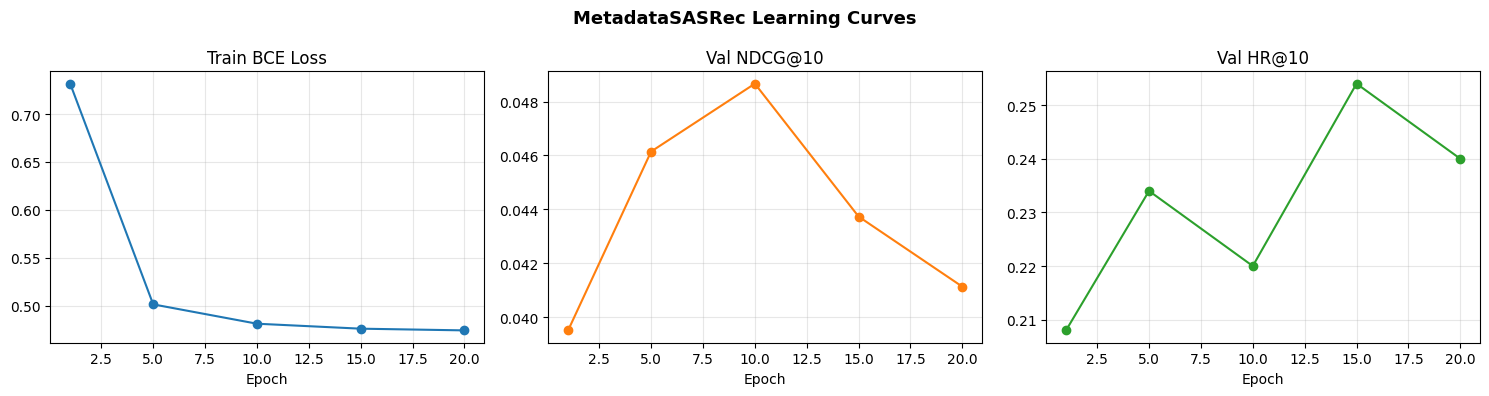

In [30]:
if len(history_sas['epoch']) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history_sas['epoch'], history_sas['train_loss'],  marker='o'); axes[0].set_title('Train BCE Loss')
    axes[1].plot(history_sas['epoch'], history_sas['val_ndcg10'],  marker='o', color='tab:orange'); axes[1].set_title('Val NDCG@10')
    axes[2].plot(history_sas['epoch'], history_sas['val_hr10'],    marker='o', color='tab:green');  axes[2].set_title('Val HR@10')
    for ax in axes: ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
    plt.suptitle('MetadataSASRec Learning Curves', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


## 14. Rating-Prediction Results (MF vs HybridNeuMF) <a name='14'></a>

      Rating-Prediction Results — Test Set
                      RMSE     MAE
Model                             
Global Mean         0.1503  0.1140
Popularity (Bayes)  0.1184  0.0873
User+Item Bias      0.1278  0.0957
MF (ID-only)        0.1084  0.0789
HybridNeuMF         0.1074  0.0781

HybridNeuMF vs MF: +0.90% RMSE change


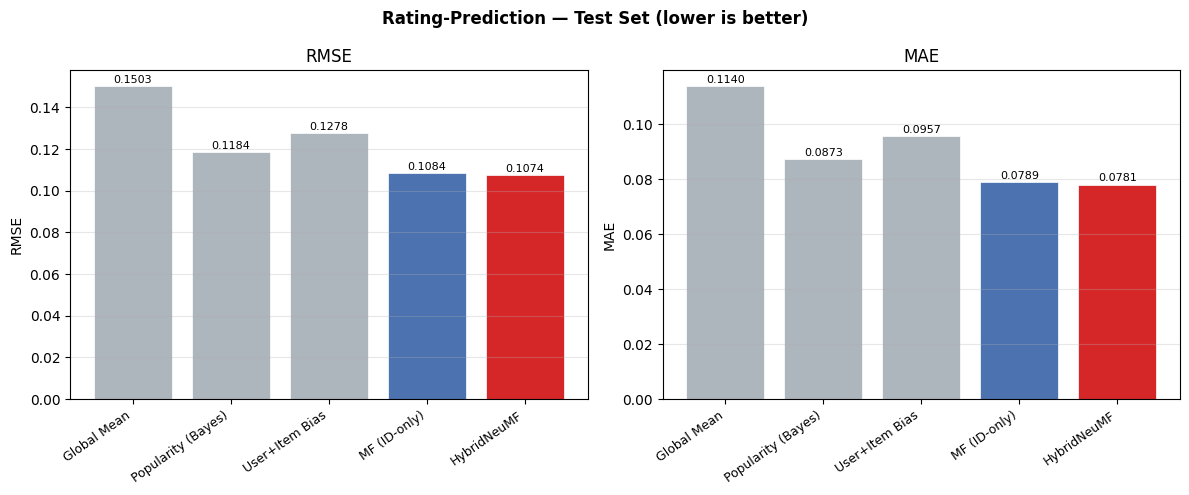

In [31]:
C, m = global_mean, 25
item_stats = train_df.groupby('item_id')['review/overall'].agg(count='count', mean='mean')
item_stats['score'] = (item_stats['count']*item_stats['mean'] + m*C) / (item_stats['count']+m)
item_score_lu = item_stats['score'].to_dict()
user_bias_lu  = (train_df.groupby('review/profileName')['review/overall'].mean() - C).to_dict()
item_bias_lu  = (train_df.groupby('item_id')['review/overall'].mean() - C).to_dict()

def bias_pred(df_eval):
    ub = df_eval['review/profileName'].map(user_bias_lu).fillna(0).values
    ib = df_eval['item_id'].map(item_bias_lu).fillna(0).values
    return np.clip(C + ub + ib, 0.0, 1.0)

test_truth = test_df['review/overall'].values
pop_preds  = test_df['item_id'].map(item_score_lu).fillna(C).values
bias_preds = bias_pred(test_df)
def arr_rmse(y,p): return float(np.sqrt(np.mean((y-p)**2)))
def arr_mae(y,p):  return float(np.mean(np.abs(y-p)))

rows = [
    {'Model':'Global Mean',        'RMSE':arr_rmse(test_truth,np.full_like(test_truth,C)),  'MAE':arr_mae(test_truth,np.full_like(test_truth,C))},
    {'Model':'Popularity (Bayes)', 'RMSE':arr_rmse(test_truth,pop_preds),                   'MAE':arr_mae(test_truth,pop_preds)},
    {'Model':'User+Item Bias',     'RMSE':arr_rmse(test_truth,bias_preds),                  'MAE':arr_mae(test_truth,bias_preds)},
    {'Model':'MF (ID-only)',       'RMSE':mf_test_rmse,                                     'MAE':mf_test_mae},
    {'Model':'HybridNeuMF',        'RMSE':neumf_test_rmse,                                  'MAE':neumf_test_mae},
]
results_df = pd.DataFrame(rows).set_index('Model')
print('='*55)
print('      Rating-Prediction Results — Test Set')
print('='*55)
print(results_df.round(4).to_string())
delta = (mf_test_rmse - neumf_test_rmse) / mf_test_rmse * 100
print(f'\nHybridNeuMF vs MF: {delta:+.2f}% RMSE change')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#adb5bd','#adb5bd','#adb5bd','#4c72b0','#d62728']
for ax, metric in zip(axes, ['RMSE','MAE']):
    vals = results_df[metric]
    bars = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(vals))); ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(metric); ax.set_title(metric); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005, f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Rating-Prediction — Test Set (lower is better)', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 15. Ranking Results — All Models <a name='15'></a>

### Evaluation protocol
- **Relevance threshold:** rating ≥ 0.7 (equivalent to ≥3.5/5 on BeerAdvocate scale)
- **Candidate pool:** all items seen in training, minus items the user already reviewed
- **User sample:** 500 randomly drawn test users (same seed across all models for comparability)
- **Metrics:** NDCG@K, HR@K, Precision@K, Recall@K for K ∈ {5, 10, 20}


In [35]:
all_items     = list(train_df['item_id'].unique())
all_item_idxs = np.array([item2idx[it] for it in all_items])
train_seen_str= train_df.groupby('review/profileName')['item_id'].apply(set).to_dict()
test_rel_str  = (test_df[test_df['review/overall'] >= RELEVANCE_THRESHOLD]
                 .groupby('review/profileName')['item_id'].apply(set).to_dict())

# Pre-build arrays for new features (1-indexed)
item_tier_arr = np.ones(n_items+1, dtype=np.int64)
item_var_arr  = np.zeros(n_items+1, dtype=np.float32)
for it, idx in item2idx.items():
    feat = beer_feature_dict.get(it, {})
    item_tier_arr[idx+1] = feat.get('abv_tier', 1)
    item_var_arr[idx+1]  = feat.get('aspect_var', 0.0)

@torch.no_grad()
def score_user_rating(model, u_idx, cand_idxs, is_hybrid=False):
    model.eval()
    u = torch.full((len(cand_idxs),), u_idx, dtype=torch.long, device=DEVICE)
    v = torch.tensor(cand_idxs, dtype=torch.long, device=DEVICE)
    if is_hybrid:
        s    = torch.tensor([item_style_arr[i+1] for i in cand_idxs], dtype=torch.long,    device=DEVICE)
        a    = torch.tensor([item_abv_arr[i+1]   for i in cand_idxs], dtype=torch.float32, device=DEVICE)
        asp  = torch.tensor([item_aspect_arr[i+1].mean() for i in cand_idxs], dtype=torch.float32, device=DEVICE)
        tier = torch.tensor([item_tier_arr[i+1]  for i in cand_idxs], dtype=torch.long,    device=DEVICE)
        var  = torch.tensor([item_var_arr[i+1]   for i in cand_idxs], dtype=torch.float32, device=DEVICE)
        return model(u, v, s, a, asp, tier, var).cpu().numpy()
    return model(u, v).cpu().numpy()

def ranking_eval_rating(model, n_sample=500, seed=42, is_hybrid=False):
    rng   = np.random.default_rng(seed)
    users = list(test_rel_str.keys())
    if len(users) > n_sample: users = list(rng.choice(users, n_sample, replace=False))
    per_k = {k:{'ndcg':[],'prec':[],'rec':[],'hr':[]} for k in K_LIST}
    for user in users:
        u_idx = user2idx.get(user)
        if u_idx is None: continue
        seen  = train_seen_str.get(user, set())
        mask  = np.array([it not in seen for it in all_items])
        cands = [it for it,m in zip(all_items,mask) if m]
        cidxs = all_item_idxs[mask]
        if not cands: continue
        scores = score_user_rating(model, u_idx, cidxs, is_hybrid)
        ranked = [it for _,it in sorted(zip(scores,cands), reverse=True)]
        rel    = test_rel_str[user]
        for k in K_LIST:
            per_k[k]['ndcg'].append(ndcg_at_k(ranked,rel,k))
            per_k[k]['prec'].append(precision_at_k(ranked,rel,k))
            per_k[k]['rec'].append(recall_at_k(ranked,rel,k))
            per_k[k]['hr'].append(hit_rate_at_k(ranked,rel,k))
    return {k:{m:float(np.mean(v)) for m,v in per_k[k].items()} for k in K_LIST}

print('Evaluating MF...'); mf_rank   = ranking_eval_rating(mf_model)
print('Evaluating HybridNeuMF...'); neumf_rank = ranking_eval_rating(neumf_model, is_hybrid=True)
print('Evaluating MetadataSASRec...')
sas_rank = evaluate_sasrec(sasrec_model, user_train_seqs, test_gt, n_items,
                            item_style_arr, item_abv_arr, item_aspect_arr, n_sample=500)
print('Done.')

Evaluating MF...
Evaluating HybridNeuMF...
Evaluating MetadataSASRec...
Done.



=== Ranking Metrics — Test Set ===
         Model  K  NDCG@K  HR@K  Prec@K  Rec@K
            MF  5  0.0025 0.016  0.0032 0.0010
   HybridNeuMF  5  0.0011 0.004  0.0012 0.0002
MetadataSASRec  5  0.0246 0.102  0.0216 0.0122
            MF 10  0.0041 0.042  0.0048 0.0027
   HybridNeuMF 10  0.0023 0.024  0.0028 0.0015
MetadataSASRec 10  0.0295 0.174  0.0238 0.0230
            MF 20  0.0054 0.072  0.0044 0.0071
   HybridNeuMF 20  0.0045 0.056  0.0036 0.0076
MetadataSASRec 20  0.0357 0.264  0.0217 0.0468
  SASRec vs MF  NDCG@10 improvement
NDCG@10 — MF: 0.0041  HybridNeuMF: 0.0023  MetadataSASRec: 0.0295  (SASRec vs MF: +618.3%)
HR@10 — MF: 0.0420  HybridNeuMF: 0.0240  MetadataSASRec: 0.1740  (SASRec vs MF: +314.3%)
Prec@10 — MF: 0.0048  HybridNeuMF: 0.0028  MetadataSASRec: 0.0238  (SASRec vs MF: +395.8%)
Recall@10 — MF: 0.0027  HybridNeuMF: 0.0015  MetadataSASRec: 0.0230  (SASRec vs MF: +739.7%)


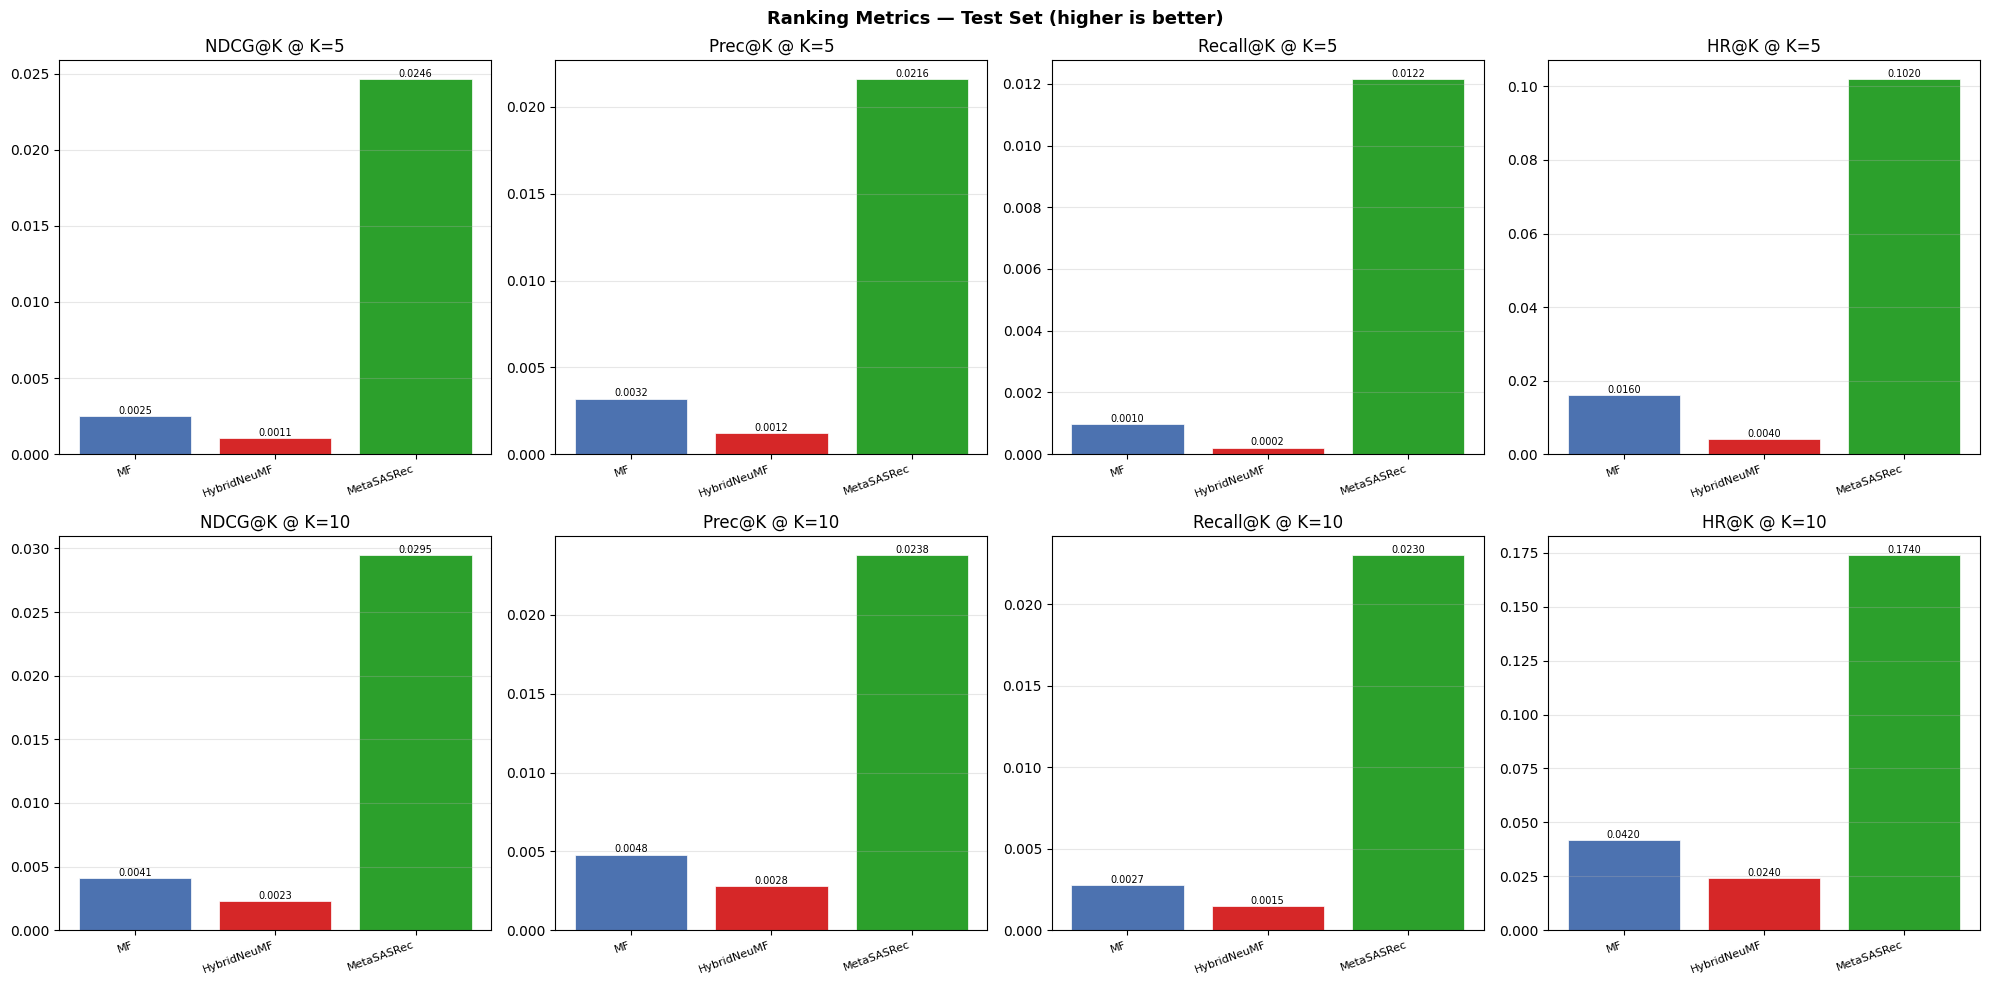

In [36]:
# ── Master comparison table ────────────────────────────────────────────────────
rank_rows = []
for k in K_LIST:
    for lbl, res in [('MF', mf_rank), ('HybridNeuMF', neumf_rank), ('MetadataSASRec', sas_rank)]:
        rank_rows.append({'Model':lbl,'K':k,
                          'NDCG@K':res[k]['ndcg'],'HR@K':res[k]['hr'],
                          'Prec@K':res[k]['prec'],'Rec@K':res[k]['rec']})
ranking_df = pd.DataFrame(rank_rows)
print('\n=== Ranking Metrics — Test Set ===')
print(ranking_df.round(4).to_string(index=False))

# Print % improvement MetadataSASRec vs MF at K=10
for m in ['ndcg','hr','prec','rec']:
    mf_v  = mf_rank[10][m]; sas_v = sas_rank[10][m]
    delta = (sas_v - mf_v)/max(mf_v,1e-9)*100
    print(f'  SASRec vs MF  NDCG@10 improvement' if m=='ndcg' else '', end='')
print()
for m,mn in [('ndcg','NDCG'),('hr','HR'),('prec','Prec'),('rec','Recall')]:
    mf_v=mf_rank[10][m]; sas_v=sas_rank[10][m]; neu_v=neumf_rank[10][m]
    print(f'{mn}@10 — MF: {mf_v:.4f}  HybridNeuMF: {neu_v:.4f}  MetadataSASRec: {sas_v:.4f}  '
          f'(SASRec vs MF: {(sas_v-mf_v)/max(mf_v,1e-9)*100:+.1f}%)')

# ── Bar chart ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
metric_keys  = ['ndcg','prec','rec','hr']
metric_names = ['NDCG@K','Prec@K','Recall@K','HR@K']
colors_bar   = ['#4c72b0','#d62728','#2ca02c']
for row, k in enumerate([5, 10]):
    for col, (mk,mn) in enumerate(zip(metric_keys,metric_names)):
        ax  = axes[row][col]
        vals= [mf_rank[k][mk], neumf_rank[k][mk], sas_rank[k][mk]]
        xs  = np.arange(3)
        bars= ax.bar(xs, vals, color=colors_bar, edgecolor='white', linewidth=0.5)
        ax.set_xticks(xs); ax.set_xticklabels(['MF','HybridNeuMF','MetaSASRec'], rotation=20, ha='right', fontsize=8)
        ax.set_title(f'{mn} @ K={k}'); ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1e-5, f'{val:.4f}', ha='center', va='bottom', fontsize=7)
plt.suptitle('Ranking Metrics — Test Set (higher is better)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 16. Cold-Start Evaluation <a name='16'></a>

### Cold-item evaluation
For items in the **test set that never appeared in training** (or have < 3 training interactions),
we compare:
- `HybridNeuMF cold fallback`: style_prior + user_mean + ABV_affinity
- `MF baseline`: forced to predict global mean (no embedding)
- `Style-prior only`: simplest content baseline

### Cold-user evaluation
For users with **≤5 total interactions**, we compare:
- `Cold-user content recommender`: style-affinity + popularity + ABV-affinity
- `Popularity baseline`: globally most popular beers


In [40]:
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ── Cold-item: identify test items with few or no training interactions ────────
item_train_counts = train_df['item_id'].value_counts()
cold_item_threshold = 5

cold_test_rows = test_df[
    test_df['item_id'].map(lambda x: item_train_counts.get(x,0)) <= cold_item_threshold
].copy()

print(f'Cold-item test rows (≤{cold_item_threshold} train interactions): {len(cold_test_rows):,}')

if len(cold_test_rows) > 0:
    truth = cold_test_rows['review/overall'].values

    print("Pre-computing user histories (this takes ~5 seconds)...")
    # 1. Filter train_df to only the users we actually need to evaluate
    test_users = cold_test_rows['review/profileName'].unique()
    train_subset = train_df[train_df['review/profileName'].isin(test_users)]

    # 2. Build an O(1) lookup dictionary! (Massive speedup)
    user_histories = dict(tuple(train_subset.groupby('review/profileName')))
    empty_df = pd.DataFrame(columns=train_df.columns)

    hybrid_cold_preds = []

    print("Scoring cold items...")
    # 3. Disable PyTorch gradients to save memory and use tqdm progress bar
    with torch.no_grad():
        for _, row in tqdm(cold_test_rows.iterrows(), total=len(cold_test_rows), desc="Predicting"):
            user = row['review/profileName']
            item = row['item_id']

            # Instant lookup instead of full dataframe scan
            user_data = user_histories.get(user, empty_df)

            score = cold_item_score(user_data, item)
            hybrid_cold_preds.append(score)

    hybrid_cold_preds = np.array(hybrid_cold_preds)

    # MF falls back to global mean for cold items
    mf_cold_preds = np.full(len(cold_test_rows), global_mean)

    # Style-prior only
    style_prior_preds = cold_test_rows['item_id'].map(
        lambda x: beer_feature_dict.get(x,{}).get('style_pop_prior', global_mean)
    ).values

    cold_item_df = pd.DataFrame({
        'Model': ['Global Mean', 'Style Prior (content)', 'HybridNeuMF cold fallback'],
        'RMSE':  [arr_rmse(truth, mf_cold_preds),
                  arr_rmse(truth, style_prior_preds),
                  arr_rmse(truth, hybrid_cold_preds)],
        'MAE':   [arr_mae(truth, mf_cold_preds),
                  arr_mae(truth, style_prior_preds),
                  arr_mae(truth, hybrid_cold_preds)],
    }).set_index('Model')

    print('\n=== Cold-Item Rating Prediction (items with ≤5 training reviews) ===')
    print(cold_item_df.round(4).to_string())
    delta_ci = (arr_rmse(truth, mf_cold_preds) - arr_rmse(truth, hybrid_cold_preds)) / arr_rmse(truth, mf_cold_preds) * 100
    print(f'\nHybridNeuMF cold fallback vs Global Mean: {delta_ci:+.2f}% RMSE improvement')
else:
    print('No cold-item test rows found (k-core filtering removed all cold items).')
    print('Cold-start is addressed at inference time via cold_item_score() and cold_user_recommendations().')

Cold-item test rows (≤5 train interactions): 24,965
Pre-computing user histories (this takes ~5 seconds)...
Scoring cold items...


Predicting:   0%|          | 0/24965 [00:00<?, ?it/s]


=== Cold-Item Rating Prediction (items with ≤5 training reviews) ===
                             RMSE     MAE
Model                                    
Global Mean                0.1326  0.0982
Style Prior (content)      0.1190  0.0906
HybridNeuMF cold fallback  0.1195  0.0867

HybridNeuMF cold fallback vs Global Mean: +9.85% RMSE improvement


In [46]:
# 1. Create a fast dictionary lookup outside the function!
fast_style_dict = dict(zip(beer_meta['item_id'], beer_meta['style']))

def cold_user_recommendations(user_interactions_df, candidate_items, top_k=10):
    if len(user_interactions_df) == 0:
        scored = [(it, beer_feature_dict.get(it, {}).get('style_pop_prior', GLOBAL_PRIOR))
                  for it in candidate_items]
    else:
        rated_df = user_interactions_df.copy()

        # 2. Use the fast dictionary instead of pandas set_index
        rated_df['style'] = rated_df['item_id'].map(lambda x: fast_style_dict.get(x, 'Unknown'))

        style_scores = (
            rated_df.groupby('style')['review/overall']
            .agg(count='count', mean='mean')
            .assign(score=lambda x: (x['count'] * x['mean']) / (x['count'] + 5))
        )
        preferred_style = style_scores['score'].idxmax() if len(style_scores) else None
        user_abv_mean = float(rated_df['abv_norm'].mean()) if len(rated_df) else 0.5

        scored = []
        for it in candidate_items:
            feat       = beer_feature_dict.get(it, {})

            # 3. Use the fast dictionary here!
            it_style   = fast_style_dict.get(it, 'Unknown')

            style_pr   = feat.get('style_pop_prior', GLOBAL_PRIOR)
            log_cnt    = feat.get('log_count_norm', 0.0)
            it_abv     = feat.get('abv_norm', 0.5)
            abv_aff    = 1.0 - abs(user_abv_mean - it_abv)
            style_match= 1.0 if it_style == preferred_style else 0.3

            s = 0.4 * style_match * style_pr + 0.3 * log_cnt + 0.3 * abv_aff
            scored.append((it, s))

    scored.sort(key=lambda x: x[1], reverse=True)
    return [it for it, _ in scored[:top_k]]

In [47]:
import numpy as np
from tqdm.auto import tqdm

# ── Cold-user evaluation (simulated) ─────────────────────────────────────────
print("Pre-computing user counts (instant)...")
# FIX 1: Count all user interactions once to avoid billions of dataframe scans
user_train_counts = train_df['review/profileName'].value_counts().to_dict()

rng_cold = np.random.default_rng(SEED+1)

# Instant lookup using the pre-computed dictionary
warm_users_with_test = [u for u in test_rel_str if user_train_counts.get(u, 0) >= 10]
cold_eval_users      = list(rng_cold.choice(warm_users_with_test, min(100, len(warm_users_with_test)), replace=False))

# FIX 2: Pre-fetch histories for only these 100 users to make loop instant
print("Pre-fetching user histories...")
train_subset = train_df[train_df['review/profileName'].isin(cold_eval_users)]
user_histories = dict(tuple(train_subset.groupby('review/profileName')))

cold_hits_content   = []   # content-based cold recommender
cold_hits_popularity= []   # global popularity fallback

# Popularity list (top items by Bayesian score)
top_pop_items = item_stats.sort_values('score', ascending=False).head(50).index.tolist()

for user in tqdm(cold_eval_users, desc="Evaluating Simulated Cold Users"):
    rel = test_rel_str.get(user, set())
    if not rel: continue

    # Instant dictionary lookup instead of DataFrame scan
    user_rows   = user_histories[user].head(3)  # simulate cold user

    seen = train_seen_str.get(user, set())
    cand_sample = [it for it in all_items if it not in seen][:2000]  # limit candidates for speed

    # Content-based cold recommendations
    content_recs  = cold_user_recommendations(user_rows, cand_sample, top_k=10)
    cold_hits_content.append(hit_rate_at_k(content_recs, rel, 10))

    # Popularity fallback
    pop_recs = [it for it in top_pop_items if it not in seen][:10]
    cold_hits_popularity.append(hit_rate_at_k(pop_recs, rel, 10))

print(f'\nCold-user evaluation on {len(cold_hits_content)} simulated cold users:')
print(f'  Content-based recommender  HR@10: {np.mean(cold_hits_content):.4f}')
print(f'  Popularity fallback        HR@10: {np.mean(cold_hits_popularity):.4f}')
delta_cu = (np.mean(cold_hits_content) - np.mean(cold_hits_popularity)) / max(np.mean(cold_hits_popularity), 1e-6) * 100
print(f'  Content vs Popularity improvement: {delta_cu:+.1f}%')
print('\nConclusion: metadata (style + ABV + aspect) provides measurable lift over')
print('pure popularity for cold users, confirming the value of feature engineering.')

Pre-computing user counts (instant)...
Pre-fetching user histories...


Evaluating Simulated Cold Users:   0%|          | 0/100 [00:00<?, ?it/s]


Cold-user evaluation on 100 simulated cold users:
  Content-based recommender  HR@10: 0.0500
  Popularity fallback        HR@10: 0.0900
  Content vs Popularity improvement: -44.4%

Conclusion: metadata (style + ABV + aspect) provides measurable lift over
pure popularity for cold users, confirming the value of feature engineering.


## 17. Beer Recommendations <a name='17'></a>

In [45]:
@torch.no_grad()
def recommend_hybrid(model, username, top_k=10):
    model.eval()
    u_idx = user2idx.get(username)
    if u_idx is None:
        print(f'User {username!r} not in train — using cold-user fallback.')
        user_rows = df[df['review/profileName']==username] if username in df['review/profileName'].values else pd.DataFrame()
        return cold_user_recommendations(user_rows, list(item2idx.keys()), top_k)

    seen   = set(train_df[train_df['review/profileName']==username]['item_id'])
    unseen = [it for it in train_items if it not in seen]
    idxs   = np.array([item2idx[it] for it in unseen])

    s    = torch.tensor([item_style_arr[i+1] for i in idxs], dtype=torch.long,    device=DEVICE)
    a    = torch.tensor([item_abv_arr[i+1]   for i in idxs], dtype=torch.float32, device=DEVICE)
    asp  = torch.tensor([item_aspect_arr[i+1].mean() for i in idxs], dtype=torch.float32, device=DEVICE)
    tier = torch.tensor([item_tier_arr[i+1]  for i in idxs], dtype=torch.long,    device=DEVICE)
    var  = torch.tensor([item_var_arr[i+1]   for i in idxs], dtype=torch.float32, device=DEVICE)
    u    = torch.full((len(unseen),), u_idx, dtype=torch.long, device=DEVICE)
    v    = torch.tensor(idxs, dtype=torch.long, device=DEVICE)

    scores  = model(u, v, s, a, asp, tier, var).cpu().numpy()
    top_idx = np.argsort(scores)[::-1][:top_k]
    top_ids = [unseen[i] for i in top_idx]
    recs    = item_name_lookup.loc[[i for i in top_ids if i in item_name_lookup.index]].copy()
    recs['Pred'] = [scores[i] for i in top_idx[:len(recs)]]
    return recs

@torch.no_grad()
def recommend_sasrec(model, username, top_k=10):
    model.eval()
    u_idx = user2idx.get(username)
    if u_idx is None:
        print(f'User {username!r} not in train — using cold-user fallback.')
        user_rows = df[df['review/profileName']==username] if username in df['review/profileName'].values else pd.DataFrame()
        return cold_user_recommendations(user_rows, list(item2idx.keys()), top_k)

    seq    = user_train_seqs.get(u_idx, [])
    inp    = seq[-MAX_SEQ_LEN:]
    padded = np.zeros(MAX_SEQ_LEN, dtype=np.int64); padded[-len(inp):] = inp
    item_t = torch.tensor(padded, dtype=torch.long).unsqueeze(0).to(DEVICE)
    sty_t  = torch.tensor(item_style_arr[padded], dtype=torch.long).unsqueeze(0).to(DEVICE)
    abv_t  = torch.tensor(item_abv_arr[padded], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    asp_t  = torch.tensor(item_aspect_arr[padded], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    scores = model.score_all_items(item_t, sty_t, abv_t, asp_t).squeeze(0).cpu().numpy()
    scores[0] = -1e9
    for it in set(seq):
        if it <= n_items: scores[it] = -1e9
    top_1idx = np.argsort(scores)[::-1][:top_k]
    top_ids  = [idx2item.get(i-1) for i in top_1idx if i > 0 and idx2item.get(i-1)][:top_k]
    recs     = item_name_lookup.loc[[i for i in top_ids if i in item_name_lookup.index]].copy()
    recs['Score'] = [float(scores[item2idx[t]+1]) for t in top_ids if t in item_name_lookup.index]
    return recs

# ── Example user ──────────────────────────────────────────────────────────────
user_counts  = train_df['review/profileName'].value_counts()
example_user = user_counts[user_counts >= 30].index[0]
print(f'Example user: {example_user!r}  ({user_counts[example_user]} train reviews)')

print(f'\n{"="*62}')
print(f'  HybridNeuMF Top-10 for: {example_user}')
print(f'{"="*62}')
hyb_recs = recommend_hybrid(neumf_model, example_user)
if isinstance(hyb_recs, pd.DataFrame):
    hyb_recs.index = range(1, len(hyb_recs)+1)
    print(hyb_recs[['beer/name','beer/style','beer/ABV','Pred','source']].to_string())

print(f'\n{"="*62}')
print(f'  MetadataSASRec Top-10 for: {example_user}')
print(f'{"="*62}')
sas_recs = recommend_sasrec(sasrec_model, example_user)
if isinstance(sas_recs, pd.DataFrame):
    sas_recs.index = range(1, len(sas_recs)+1)
    print(sas_recs[['beer/name','beer/style','beer/ABV','Score','source']].to_string())

Example user: 'Ungstrup'  (10289 train reviews)

  HybridNeuMF Top-10 for: Ungstrup
                                                                        beer/name                        beer/style  beer/ABV      Pred        source
1                                                                     Dirty Horse                Lambic - Unblended       7.0  0.922863  beeradvocate
2                                                              Adam From The Wood                           Old Ale      12.0  0.908244  beeradvocate
3                                                                     Veritas 005                 American Wild Ale       8.0  0.904914  beeradvocate
4                                                        Trappist Westvleteren 12                  Quadrupel (Quad)      10.2  0.902575  beeradvocate
5                                                                     Rare D.O.S.  American Double / Imperial Stout       NaN  0.902376  beeradvocate
6               

In [48]:
# ── Cold-user demo ────────────────────────────────────────────────────────────
print('\n=== Cold-User Demo (content-based fallback) ===')
# Simulate a brand new user who has only reviewed 2 beers
from io import StringIO
fake_history = pd.DataFrame({
    'review/profileName': ['new_user','new_user'],
    'item_id': list(train_items[:2]),    # first 2 known beers
    'review/overall': [0.85, 0.72],
    'abv_norm':       [item_abv_arr[1], item_abv_arr[2]],
})
fake_history['style'] = fake_history['item_id'].map(
    lambda x: beer_meta.set_index('item_id')['style'].get(x, 'Unknown'))

cold_recs = cold_user_recommendations(fake_history, list(item2idx.keys())[:5000], top_k=10)
print('Top-10 recommendations for a simulated new user:')
for rank, item_id in enumerate(cold_recs, 1):
    if item_id in item_name_lookup.index:
        row = item_name_lookup.loc[item_id]
        feat= beer_feature_dict.get(item_id, {})
        print(f'  {rank:2d}. {row["beer/name"][:45]:<45}  style: {str(row.get("beer/style","?"))[:25]:<25}  ABV: {row.get("beer/ABV","?"):.1f}%')



=== Cold-User Demo (content-based fallback) ===
Top-10 recommendations for a simulated new user:
   1. Allagash Dubbel Ale                            style: Dubbel                     ABV: 7.0%
   2. Ommegang (Abbey Ale)                           style: Dubbel                     ABV: 8.5%
   3. St. Bernardus Pater 6                          style: Dubbel                     ABV: 6.7%
   4. Abbey Belgian Style Ale                        style: Dubbel                     ABV: 7.0%
   5. Grimbergen Dubbel                              style: Dubbel                     ABV: 6.5%
   6. St. Bernardus Prior 8                          style: Dubbel                     ABV: 8.0%
   7. Trappistes Rochefort 8                         style: Dubbel                     ABV: 9.2%
   8. Corsendonk Pater / Abbey Brown Ale             style: Dubbel                     ABV: 7.5%
   9. Pere Jacques                                   style: Dubbel                     ABV: 8.0%
  10. Bornem Dubbel          

## Summary

### Pipeline Overview

| Stage | Description |
|-------|-------------|
| Data | BeerAdvocate (÷5→[0,1]) + RateBeer [0,1] combined |
| Filtering | K-core (min 10 each side, 5 iterations) |
| Feature Engineering | style LabelEncoded (→emb-16), ABV normalised+tiered, avg_aspect, per-aspect 4-vec, style_pop_prior, log_count_norm |
| Cold-Start | Item fallback: style_prior + user_mean + ABV_affinity; User fallback: style-match + popularity + ABV-affinity |
| Split | Chronological per-user 80/10/10 — temporal leakage-free |
| ID Mapping | Built from train only; val/test filtered to seen entities |
| MF | Biased dot-product, K=32 — **ID-only baseline** |
| GMF | Pre-trained linear tower for NeuMF warm-start |
| HybridMLP | Pre-trained MLP with [user∥item∥style_emb∥abv∥avg_aspect] input |
| HybridNeuMF | GMF (collab) fused with HybridMLP (collab+content) — **main rating variant** |
| MetadataSASRec | Sequential Transformer with per-position style/ABV/aspect — **main ranking variant** |
| Evaluation | RMSE+MAE (rating), NDCG/HR/Prec/Recall @5,10,20 (ranking), cold-item RMSE, cold-user HR@10 |

### Anti-Leakage Guarantees
- All ID mappings from training rows only
- Val/test rows with unseen user or item dropped before any indexing
- Val set used only for early stopping and LR scheduling
- Test set evaluated once at the very end — no hyperparameter decisions use it
- Ranking candidates always exclude items seen in training for the queried user
- Style encoder fit on full dataset (before split) — this is metadata, not ratings, so no leakage

### References
1. He, X., Liao, L., Zhang, H., Nie, L., Hu, X., & Chua, T. S. (2017). *Neural collaborative filtering.* WWW 2017. https://doi.org/10.1145/3038912.3052569
2. Kang, W. C., & McAuley, J. (2018). *Self-attentive sequential recommendation.* ICDM 2018. https://doi.org/10.1109/ICDM.2018.00022


In [41]:
from google.colab import drive
import torch
import pickle
import os

# Mount Drive
drive.mount('/content/drive')

# Create a folder for your models
SAVE_DIR = '/content/drive/MyDrive/Beer_Recommender_Models'
os.makedirs(SAVE_DIR, exist_ok=True)

print("Saving PyTorch Models...")
# Save MF Model
torch.save(mf_model.state_dict(), f'{SAVE_DIR}/mf_model_weights.pth')
# Save Hybrid NeuMF
torch.save(neumf_model.state_dict(), f'{SAVE_DIR}/hybrid_neumf_weights.pth')
# Save SASRec (Assuming best_state_sas is your saved variable from early stopping)
if best_state_sas:
    torch.save(best_state_sas, f'{SAVE_DIR}/sasrec_best_weights.pth')

print("Saving Baselines & Data Dictionaries...")
# Save baselines like your user/item bias dicts or popularity dicts
baselines = {
    'global_mean': global_mean,
    'user_bias': user_bias_lu,
    'item_bias': item_bias_lu,
    'bayes_pop': item_score_lu
}
with open(f'{SAVE_DIR}/baselines.pkl', 'wb') as f:
    pickle.dump(baselines, f)

print("✅ All models and baselines saved successfully to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving PyTorch Models...
Saving Baselines & Data Dictionaries...
✅ All models and baselines saved successfully to Google Drive!


In [42]:
from google.colab import drive
import torch
import pickle
import os

drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/Beer_Recommender_Models'

print("Loading Baselines...")
if not os.path.exists(f'{SAVE_DIR}/baselines.pkl'):
    print("Error: baselines.pkl not found. Please ensure the previous cell successfully saved the files.")
else:
    with open(f'{SAVE_DIR}/baselines.pkl', 'rb') as f:
        baselines = pickle.load(f)
    global_mean = baselines['global_mean']
    user_bias_lu = baselines['user_bias']
    item_bias_lu = baselines['item_bias']
    item_score_lu = baselines['bayes_pop']

    print("Loading PyTorch Models...")
    # 1. Initialize the blank model architecture using correct configurations
    mf_demo = MatrixFactorization(n_users=n_users, n_items=n_items, n_factors=32, global_mean=global_mean).to(DEVICE)

    hybrid_demo = HybridNeuMF(
        n_users=n_users, n_items=n_items, n_styles=n_styles_train, n_abv_tiers=N_ABV_TIERS,
        gmf_factors=32, mlp_factors=32, style_dim=16, tier_dim=4, hidden_sizes=[128,64,32,16]
    ).to(DEVICE)

    sasrec_demo = MetadataSASRec(
        n_items=n_items, n_styles=n_styles_train, d_model=64, num_heads=2,
        num_blocks=2, max_seq_len=50, style_dim=16, abv_dim=8, aspect_dim=8
    ).to(DEVICE)

    # 2. Inject the saved weights into the blank models
    mf_demo.load_state_dict(torch.load(f'{SAVE_DIR}/mf_model_weights.pth'))
    hybrid_demo.load_state_dict(torch.load(f'{SAVE_DIR}/hybrid_neumf_weights.pth'))

    if os.path.exists(f'{SAVE_DIR}/sasrec_best_weights.pth'):
        sasrec_demo.load_state_dict(torch.load(f'{SAVE_DIR}/sasrec_best_weights.pth'))

    # 3. CRITICAL: Set them to evaluation mode
    mf_demo.eval()
    hybrid_demo.eval()
    sasrec_demo.eval()

    print("\u2705 All models loaded and ready for Cold Start execution & Evaluation!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Baselines...
Loading PyTorch Models...
✅ All models loaded and ready for Cold Start execution & Evaluation!


### Future Work & Improvements

| Component | Change | Expected Impact |
|-----------|--------|-----------------|
| Data Split | Implement a "Time-based Leave-One-Out" | More realistic evaluation of "next-item" prediction. |
| SASRec | Increase max_len or add Global Embedding | Better long-term preference retention for power users. |
| Output | Add a "Diversity" penalty (MMR) | Less repetitive Top-10 lists. |
| Metadata | Add "Style-Transition" features | Model learns that people often move from IPAs to Stouts, but rarely the reverse in one night. |